# Ingresos laborales dependientes en el Perú — ENAHO 2025

**Informe reproducible de análisis económico y modelos predictivos**  
Autor de esta adaptación: Johan Jordan Serna Meza · Economía

## Resumen ejecutivo

Este proyecto analiza cómo varía el **ingreso laboral de trabajadores dependientes en el Perú** según educación, sexo, área de residencia y actividad económica, y evalúa en qué medida estas características permiten predecir el ingreso.

A partir de los microdatos de la **ENAHO 2025**, se construyó una muestra analítica de **23 125 empleados y obreros** con ingreso positivo en la ocupación principal. Los resultados descriptivos muestran diferencias relevantes: el ingreso mensual equivalente promedio es de **S/ 1 914 para hombres** y **S/ 1 672 para mujeres**, mientras que alcanza **S/ 1 902 en áreas urbanas** y **S/ 1 155 en áreas rurales**. También se observa una asociación positiva entre educación e ingreso: los promedios ascienden a **S/ 1 426 para secundaria**, **S/ 2 442 para educación universitaria** y **S/ 4 733 para posgrado**.

Para el análisis predictivo se comparó un **modelo lineal de ingresos** con una **red neuronal** utilizando el mismo conjunto de prueba. El modelo lineal obtuvo un **R² aproximado de 0,531**, mientras que la red neuronal alcanzó **0,600**, mostrando una mayor capacidad predictiva dentro de este ejercicio.

En conjunto, los resultados evidencian asociaciones importantes entre ingreso y características educativas, demográficas y laborales. Sin embargo, las brechas y coeficientes obtenidos **no deben interpretarse como efectos causales**.

El proyecto amplía un trabajo académico grupal de Ciencia de Datos Aplicada mediante su aplicación a **microdatos reales de ENAHO 2025**. La base simplificada utilizada originalmente no se reutiliza como información oficial y se reconoce a **Emilio Augusto Vera Meza** como compañero del trabajo de origen.


## 1. Datos y alcance

La unidad de análisis es la **persona**. Se vinculan los módulos 200 (características de las personas), 300 (educación) y 500 (empleo e ingresos) con las claves `conglome`, `vivienda`, `hogar` y `codperso`. La muestra se restringe a ocupados cuya ocupación principal es empleado u obrero. Por tanto, las conclusiones no abarcan directamente a independientes, empleadores, desocupados ni a todas las personas del país.

| Variable ENAHO | Módulo | Uso en el análisis |
|---|---:|---|
| `p207`, `p208a`, `estrato` | 200 | Sexo, edad y aproximación de área urbana/rural |
| `ubigeo` | 200 | Identificación geográfica disponible |
| `p301a`, `p301b`, `p301c` | 300 | Nivel y grado para aproximar años de educación |
| `ocu500`, `p507` | 500 | Selección de ocupados empleados u obreros |
| `p506r4` | 500 | Actividad económica CIIU revisión 4, agrupada en sectores |
| `p513t` | 500 | Horas en la ocupación principal la semana anterior |
| `p511a` | 500 | Condición de contrato; no es una medida oficial de formalidad |
| `p524a1` | 500 | Ingreso reportado en campo; referencia adicional |
| **`i524a1`** | **500** | **Ingreso monetario anualizado, imputado y ajustado; base del ingreso mensual equivalente** |
| `fac500a` | 500 | Factor usado para medias descriptivas ponderadas |

**Variables construidas:** `ingreso_mensual_soles = i524a1 / 12`; `ln_ingreso = log(ingreso_mensual_soles)`; años de educación aproximados a partir de nivel y grado; `experiencia_potencial = edad − educación aproximada − 6`. Esta experiencia es potencial, no años trabajados declarados. `sector` y `contrato` son agrupaciones analíticas.


## 2.  Entorno de trabajo

Se leen solo las variables necesarias. Cada módulo debe tener una fila por persona; la unión comprueba unicidad y correspondencia de claves antes de continuar.


In [ ]:
# ============================================================
# SECCIÓN 0. PREPARACIÓN E INTEGRACIÓN DE LOS DATOS ENAHO
# ============================================================


# ============================================================
# 0.1 IMPORTACIÓN DE LIBRERÍAS
# ============================================================

from pathlib import Path
from zipfile import ZipFile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# Semilla para que los resultados aleatorios sean reproducibles.
SEED = 42
np.random.seed(SEED)


# ============================================================
# 0.2 UBICACIÓN DE LOS ARCHIVOS
# ============================================================

DATA_DIR = Path('data/raw')

assert DATA_DIR.exists(), (
    f'No encuentro la carpeta {DATA_DIR.resolve()}. '
    'Coloca allí los módulos ENAHO en formato .dta o .zip.'
)


# ============================================================
# 0.3 FUNCIÓN PARA CARGAR LOS MÓDULOS
# ============================================================

def cargar_modulo(numero, sufijo, columnas):
    """
    Carga un módulo ENAHO.

    Primero busca el archivo .dta ya extraído.
    Si no existe, busca el ZIP correspondiente y lee
    directamente el .dta contenido en él.
    """

    # --------------------------------------------------------
    # Caso 1: el archivo .dta ya está extraído
    # --------------------------------------------------------

    archivo_dta = DATA_DIR / sufijo

    if archivo_dta.is_file():

        return pd.read_stata(
            archivo_dta,
            columns=columnas,
            convert_categoricals=False
        )


    # --------------------------------------------------------
    # Caso 2: buscar el módulo dentro de un ZIP
    # --------------------------------------------------------

    encontrados = sorted(
        DATA_DIR.glob(f'*Modulo{numero:02d}*.zip')
    )

    if len(encontrados) != 1:

        raise FileNotFoundError(
            f'Se esperaba un .dta o un solo ZIP del módulo '
            f'{numero} en {DATA_DIR}. '
            f'Encontrados: {encontrados}'
        )


    # --------------------------------------------------------
    # Abrir ZIP y localizar el archivo .dta
    # --------------------------------------------------------

    with ZipFile(encontrados[0]) as z:

        candidatos = [
            archivo
            for archivo in z.namelist()
            if archivo.lower().endswith(sufijo.lower())
        ]

        if len(candidatos) != 1:

            raise ValueError(
                f'No se encontró exactamente un archivo '
                f'{sufijo} dentro de {encontrados[0]}'
            )

        with z.open(candidatos[0]) as f:

            return pd.read_stata(
                f,
                columns=columnas,
                convert_categoricals=False
            )


# ============================================================
# 0.4 CLAVE DE IDENTIFICACIÓN DE LA PERSONA
# ============================================================

# La combinación de estas cuatro variables identifica
# a una persona dentro de los módulos ENAHO.

CLAVE = [
    'conglome',
    'vivienda',
    'hogar',
    'codperso'
]


# ============================================================
# 0.5 CARGA DE LOS MÓDULOS
# ============================================================

# ------------------------------------------------------------
# Módulo 200: características de la persona
# ------------------------------------------------------------

personas = cargar_modulo(
    2,
    'enaho01-2025-200.dta',
    CLAVE + [
        'p207',       # sexo
        'p208a',      # edad
        'estrato',
        'ubigeo'
    ]
)

# ------------------------------------------------------------
# Revisar variables TIC disponibles en el módulo 300
# ------------------------------------------------------------

educacion_completa = pd.read_stata(
    DATA_DIR / 'enaho01a-2025-300.dta',
    convert_categoricals=False
)

variables_tic = [
    col for col in educacion_completa.columns
    if col.lower().startswith('p316')
]

#print('Variables TIC encontradas:')
#print(variables_tic)


ruta_500 = DATA_DIR / 'enaho01a-2025-500.dta'

empleo_completo = pd.read_stata(
    ruta_500,
    convert_categoricals=False
)


# ------------------------------------------------------------
# Módulo 300: educación
# ------------------------------------------------------------

educacion = cargar_modulo(
    3,
    'enaho01a-2025-300.dta',
    CLAVE + [
        'p301a',      # nivel educativo
        'p301b',      # último año aprobado
        'p301c',       # último grado aprobado

                                # Variables TIC candidatas
        'p316b',
        'p316c1',
        'p316c2',
        'p316c3',
        'p316c4',
        'p316c5',
        'p316c6',
        'p316c7',
        'p316c8',
        'p316c9',
        'p316c10'
    ]
)

# ------------------------------------------------------------
# Módulo 400: salud
# ------------------------------------------------------------

salud = cargar_modulo(
    4,
    'enaho01a-2025-400.dta',
    CLAVE + [
        # Seguro de salud al que está afiliado
        'p4191',      # EsSalud
        'p4192',      # Seguro privado
        'p4193',      # EPS
        'p4194',      # FF.AA. / Policial
        'p4195',      # SIS
        'p4196',      # Seguro universitario
        'p4197',      # Seguro escolar privado
        'p4198',      # Otro

        # Quién aporta las cuotas del seguro
        'p419a1',
        'p419a2',
        'p419a3',
        'p419a4',
        'p419a5',
        'p419a6',
        'p419a7',
        'p419a8'
    ]
)


# ------------------------------------------------------------
# Módulo 500: empleo e ingresos
# ------------------------------------------------------------

empleo = cargar_modulo(
    5,
    'enaho01a-2025-500.dta',
    CLAVE + [
        'ocu500',     # condición de ocupación
        'p507',       # categoría ocupacional
        'p506r4',     # actividad económica
        'p512a',      # tamaño del establecimiento
        'p512b',      # número de trabajadores
        'p513t',      # horas trabajadas
        
        'dominio',    # ubicación geográfica
        
        'p510a1',     # identifica si el negocio está registrado en SUNAT
        
        'p511a',      # tipo de contrato
        'p524a1',     # ingreso declarado
        'i524a1',     # ingreso anual ajustado
        'fac500a'     # factor de expansión
    ]
)


# ============================================================
# 0.6 RESUMEN DE LOS MÓDULOS CARGADOS
# ============================================================

tabla_modulos = pd.DataFrame({
    'Módulo': [
        '200 - Personas',
        '300 - Educación',
        '400 - Salud',
        '500 - Empleo'
    ],
    'Observaciones': [
        len(personas),
        len(educacion),
        len(salud),
        len(empleo)
    ]
})

print('--- Módulos ENAHO cargados ---')
display(tabla_modulos)


# ============================================================
# 0.7 REVISIÓN DE DUPLICADOS ANTES DEL MERGE
# ============================================================

# Aquí verificamos que una misma persona no aparezca
# repetida dentro de cada módulo.

resumen_duplicados = []

for nombre, tabla in [
    ('200', personas),
    ('300', educacion),
    ('400', salud),
    ('500', empleo)
]:
    n_duplicados = tabla.duplicated(CLAVE).sum()

    resumen_duplicados.append({
        'Módulo': nombre,
        'Duplicados por clave': n_duplicados,
        'Estado': (
            'Sin duplicados'
            if n_duplicados == 0
            else 'Revisar'
        )
    })


tabla_duplicados = pd.DataFrame(resumen_duplicados)

print('\n--- Revisión de duplicados por persona ---')
display(tabla_duplicados)


if tabla_duplicados['Duplicados por clave'].sum() > 0:

    print(
        '\nADVERTENCIA: Se encontraron duplicados por clave. '
        'Conviene revisarlos antes de realizar el merge.'
    )

else:

    print('\nNo se encontraron duplicados por clave.')


# ============================================================
# 0.8 UNIÓN DE LOS MÓDULOS
# ============================================================

# Utilizamos el módulo 500 como base porque el análisis
# está centrado en empleo e ingresos.


# ------------------------------------------------------------
# Empleo + características personales
# ------------------------------------------------------------

data_frame = empleo.merge(
    personas,
    on=CLAVE,
    how='left',
    validate='one_to_one',
    indicator=True
)

assert (data_frame['_merge'] == 'both').all(), (
    'Hay personas del módulo 500 sin correspondencia '
    'en el módulo 200.'
)

data_frame = data_frame.drop(columns='_merge')


# ------------------------------------------------------------
# Agregar información educativa
# ------------------------------------------------------------

data_frame = data_frame.merge(
    educacion,
    on=CLAVE,
    how='left',
    validate='one_to_one',
    indicator=True
)

assert (data_frame['_merge'] == 'both').all(), (
    'Hay personas del módulo 500 sin correspondencia '
    'en el módulo 300.'
)

data_frame = data_frame.drop(columns='_merge')

# ------------------------------------------------------------
# Agregar información de salud
# ------------------------------------------------------------

data_frame = data_frame.merge(
    salud,
    on=CLAVE,
    how='left',
    validate='one_to_one',
    indicator=True
)

n_sin_salud = (data_frame['_merge'] != 'both').sum()

print(
    f'Personas del módulo 500 sin correspondencia '
    f'en módulo 400: {n_sin_salud:,}'
)

data_frame = data_frame.drop(columns='_merge')


# ============================================================
# 0.9 RESULTADO DE LA INTEGRACIÓN
# ============================================================

print(
    f'\nBase integrada correctamente: '
    f'{len(data_frame):,} observaciones '
    f'y {data_frame.shape[1]} variables.'
)


# ============================================================
# 0.10 VISTA DE LOS DATOS INTEGRADOS
# ============================================================

# Estos nombres se utilizan únicamente para facilitar
# la lectura de la vista previa.
# data_frame conserva los nombres originales de ENAHO.

nombres_legibles = {
    'p207': 'sexo',
    'p208a': 'edad',
    'p507': 'categoria_ocupacional',
    'p301a': 'nivel_educativo',
    'p506r4': 'actividad_economica',
    'p513t': 'horas_trabajadas',
    'p511a': 'tipo_contrato',
    'p524a1': 'ingreso_total_declarado',
    'i524a1': 'ingreso_anual_ajustado',
    'fac500a': 'factor_expansion',
    'p301b': 'ultimo_anio_aprobado',
    'p301c': 'ultimo_grado_aprobado'
}


vista_previa = (
    data_frame
    .head(7)
    .rename(columns=nombres_legibles)
)

vista_previa_tail = (
    data_frame
    .tail(7)
    .rename(columns=nombres_legibles)
)


print('\n--- Primeras observaciones de la base integrada ---')
display(vista_previa)

print('\n--- Últimas observaciones de la base integrada ---')
display(vista_previa_tail)
#copia para luego hacer el análisis de redes neuronales 
data_frame_original = data_frame.copy()



--- Módulos ENAHO cargados ---


,Módulo,Observaciones
0,200 - Personas,115145
1,300 - Educación,104446
2,400 - Salud,107802
3,500 - Empleo,84853



--- Revisión de duplicados por persona ---


,Módulo,Duplicados por clave,Estado
0,200,0,Sin duplicados
1,300,0,Sin duplicados
2,400,0,Sin duplicados
3,500,0,Sin duplicados



No se encontraron duplicados por clave.
Personas del módulo 500 sin correspondencia en módulo 400: 0

Base integrada correctamente: 84,853 observaciones y 50 variables.

--- Primeras observaciones de la base integrada ---


,conglome,vivienda,hogar,codperso,ocu500,categoria_ocupacional,actividad_economica,p512a,p512b,horas_trabajadas,...,p4197,p4198,p419a1,p419a2,p419a3,p419a4,p419a5,p419a6,p419a7,p419a8
0,015009,012,11,01,1.0,3.0,8510.0,5.0,9998.0,0.0,...,2.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,015009,012,11,02,1.0,2.0,4799.0,1.0,1.0,14.0,...,2.0,2.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN
2,015009,025,11,01,1.0,1.0,4322.0,1.0,2.0,48.0,...,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,015009,025,11,02,1.0,2.0,9601.0,1.0,1.0,6.0,...,2.0,2.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN
4,015009,025,11,03,4.0,NaN,NaN,NaN,NaN,NaN,...,2.0,2.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN
5,015009,025,11,04,4.0,NaN,NaN,NaN,NaN,NaN,...,2.0,2.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN
6,015009,049,11,01,1.0,3.0,8610.0,2.0,30.0,48.0,...,2.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- Últimas observaciones de la base integrada ---


,conglome,vivienda,hogar,codperso,ocu500,categoria_ocupacional,actividad_economica,p512a,p512b,horas_trabajadas,...,p4197,p4198,p419a1,p419a2,p419a3,p419a4,p419a5,p419a6,p419a7,p419a8
84846,020859,056,11,01,1.0,2.0,111.0,1.0,2.0,56.0,...,2.0,2.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN
84847,020859,056,11,02,1.0,5.0,111.0,1.0,2.0,50.0,...,2.0,2.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN
84848,020859,068,11,01,1.0,4.0,4100.0,1.0,4.0,40.0,...,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
84849,020859,079,11,01,1.0,4.0,4100.0,1.0,4.0,58.0,...,2.0,2.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN
84850,020859,079,11,02,1.0,2.0,111.0,1.0,2.0,48.0,...,2.0,2.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN
84851,020859,079,11,03,4.0,5.0,111.0,1.0,3.0,8.0,...,2.0,2.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN
84852,020859,091,11,01,1.0,2.0,150.0,1.0,1.0,46.0,...,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Carga y exploración inicial

En esta sección se examina la base integrada **antes de aplicar cualquier criterio de limpieza o selección de la muestra**. El objetivo es conocer su estructura e identificar posibles problemas de calidad que deban tratarse posteriormente.

Se revisan las **dimensiones de la base**, los **tipos de datos**, las **primeras observaciones**, las **estadísticas descriptivas**, los **valores faltantes** y la presencia de **duplicados**.


In [ ]:
# ============================================================
# 1. CARGA Y EXPLORACIÓN INICIAL
# ============================================================

# En esta sección examinamos la base integrada antes de aplicar
# cualquier criterio de limpieza o selección de la muestra.


# ============================================================
# 1.1 DIMENSIONES DEL DATAFRAME
# ============================================================

print('--- Dimensiones del DataFrame ---')

n_filas, n_columnas = data_frame.shape

print(f'Número de observaciones: {n_filas:,}')
print(f'Número de variables: {n_columnas}')


# ============================================================
# 1.2 INFORMACIÓN GENERAL Y TIPOS DE DATOS
# ============================================================

print('\n--- Información general del DataFrame ---')

data_frame.info()


# ============================================================
# 1.3 PRIMERAS OBSERVACIONES
# ============================================================

print('\n--- Primeras observaciones ---')

display(data_frame.head(7))


# ============================================================
# 1.4 ESTADÍSTICAS DESCRIPTIVAS
# ============================================================

print('\n--- Estadísticas descriptivas de variables numéricas ---')

display(
    data_frame
    .describe()
    .T
)


# ============================================================
# 1.5 VALORES FALTANTES
# ============================================================

tabla_faltantes = (
    pd.DataFrame({
        'Faltantes': data_frame.isna().sum(),
        'Porcentaje (%)': (
            data_frame.isna().mean() * 100
        ).round(2)
    })
    .reset_index()
    .rename(columns={'index': 'Variable'})
    .sort_values(
        'Porcentaje (%)',
        ascending=False
    )
)


# ============================================================
# 1.6 DUPLICADOS
# ============================================================

duplicados_exactos = (
    data_frame
    .duplicated()
    .sum()
)

duplicados_clave = (
    data_frame
    .duplicated(subset=CLAVE)
    .sum()
)

tabla_duplicados = pd.DataFrame({
    'Criterio': [
        'Filas completamente duplicadas',
        'Personas duplicadas según CLAVE'
    ],
    'Duplicados': [
        duplicados_exactos,
        duplicados_clave
    ],
    'Estado': [
        'Sin duplicados' if duplicados_exactos == 0 else 'Revisar',
        'Sin duplicados' if duplicados_clave == 0 else 'Revisar'
    ]
})

print('\n--- Revisión de duplicados ---')

display(tabla_duplicados)


# ============================================================
# 1.7 TIPOS DE DATOS POR VARIABLE
# ============================================================

tabla_tipos = (
    data_frame.dtypes
    .astype(str)
    .reset_index()
    .rename(columns={'index': 'Variable', 0: 'Tipo'})
    .groupby('Tipo')['Variable']
    .apply(lambda x: ', '.join(x))
    .reset_index()
)

print('\n--- Tipos de datos por variable ---')
display(tabla_tipos)


# ============================================================
# 1.8 VARIABLES CODIFICADAS NUMÉRICAMENTE
# ============================================================

variables_codificadas = [
    # Situación laboral
    'ocu500',
    'p507',
    'p506r4',
    'p512a',
    'p511a',

    # Geografía / características individuales
    'dominio',
    'p207',
    'estrato',

    # Educación
    'p301a',

    # TIC
    'p316b',
    'p316c1',
    'p316c2',
    'p316c3',
    'p316c4',
    'p316c5',
    'p316c6',
    'p316c7',
    'p316c8',
    'p316c9',
    'p316c10'
]

variables_codificadas = [
    var
    for var in variables_codificadas
    if var in data_frame.columns
]

tabla_codificadas = pd.DataFrame({
    'Variable': variables_codificadas,
    'Tipo actual': [
        str(data_frame[var].dtype)
        for var in variables_codificadas
    ],
    'Interpretación': (
        'Variable categórica codificada numéricamente'
    )
})

print(
    '\n--- Variables que requieren atención '
    'por su interpretación ---'
)

display(tabla_codificadas)


# ============================================================
# 1.9 RESUMEN AUTOMÁTICO
# ============================================================

n_variables_con_faltantes = (
    data_frame
    .isna()
    .any()
    .sum()
)


# ============================================================
# RESUMEN COMPACTO PARA REVISIÓN
# ============================================================

print('DIMENSIONES')
print(data_frame.shape)


print('\nDUPLICADOS')
display(tabla_duplicados)

print('\nRANGOS PRINCIPALES')
variables_revision = [
    'p208a',
    'p513t',
    'p524a1',
    'i524a1',
    'p301a',
    'p512a',
    'dominio',
    'p316b',
    'p316c1',
    'p316c9'
]

display(
    data_frame[variables_revision]
    .describe()
    .T
)

print('\nRESUMEN')
print(
    f'N = {len(data_frame):,} | '
    f'Variables = {data_frame.shape[1]} | '
    f'Con faltantes = {data_frame.isna().any().sum()} | '
    f'Duplicados exactos = {data_frame.duplicated().sum()} | '
    f'Duplicados CLAVE = {data_frame.duplicated(CLAVE).sum()}'
)

# ============================================================
# RESUMEN COMPLETO DE LAS 33 VARIABLES
# ============================================================

resumen_variables = pd.DataFrame({
    'Variable': data_frame.columns,
    'Tipo': data_frame.dtypes.astype(str).values,
    'No_nulos': data_frame.notna().sum().values,
    'Faltantes': data_frame.isna().sum().values,
    'Faltantes_%': (
        data_frame.isna().mean().mul(100).round(2).values
    ),
    'Valores_unicos': [
        data_frame[col].nunique(dropna=True)
        for col in data_frame.columns
    ]
})


# ------------------------------------------------------------
# Clasificación conceptual de las variables
# ------------------------------------------------------------

tipo_conceptual = {

    # Identificación
    'conglome': 'Identificador',
    'vivienda': 'Identificador',
    'hogar': 'Identificador',
    'codperso': 'Identificador',
    'ubigeo': 'Identificador geográfico',

    # Empleo
    'ocu500': 'Categórica - condición de ocupación',
    'p507': 'Categórica - categoría ocupacional',
    'p506r4': 'Categórica - actividad económica',
    'p512a': 'Categórica - tamaño del establecimiento',
    'p512b': 'Cuantitativa - número de trabajadores',
    'dominio': 'Categórica - dominio geográfico',
    'p513t': 'Cuantitativa - horas trabajadas',
    'p511a': 'Categórica - tipo de contrato',
    'p524a1': 'Cuantitativa - ingreso declarado',
    'i524a1': 'Cuantitativa - ingreso anual ajustado',
    'fac500a': 'Cuantitativa - factor de expansión',

    # Persona
    'p207': 'Categórica - sexo',
    'p208a': 'Cuantitativa - edad',
    'estrato': 'Categórica - estrato',

    # Educación
    'p301a': 'Categórica - nivel educativo',
    'p301b': 'Educativa - año aprobado',
    'p301c': 'Educativa - grado aprobado',

    # TIC
    'p316b': 'Categórica binaria - uso de computadora',
    'p316c1': 'Categórica binaria - habilidad TIC',
    'p316c2': 'Categórica binaria - habilidad TIC',
    'p316c3': 'Categórica binaria - habilidad TIC',
    'p316c4': 'Categórica binaria - habilidad TIC',
    'p316c5': 'Categórica binaria - habilidad TIC',
    'p316c6': 'Categórica binaria - habilidad TIC',
    'p316c7': 'Categórica binaria - habilidad TIC',
    'p316c8': 'Categórica binaria - habilidad TIC',
    'p316c9': 'Categórica binaria - habilidad TIC',
    'p316c10': 'Categórica binaria - otra habilidad TIC'
}

resumen_variables['Interpretacion'] = (
    resumen_variables['Variable']
    .map(tipo_conceptual)
)




# ============================================================
# RESUMEN GENERAL
# ============================================================

print('\n--- RESUMEN GENERAL ---')

print(f'Observaciones: {len(data_frame):,}')
print(f'Variables: {data_frame.shape[1]}')

print(
    'Variables con faltantes:',
    data_frame.isna().any().sum()
)

print(
    'Duplicados exactos:',
    data_frame.duplicated().sum()
)

print(
    'Duplicados por CLAVE:',
    data_frame.duplicated(CLAVE).sum()
)




--- Dimensiones del DataFrame ---
Número de observaciones: 84,853
Número de variables: 50

--- Información general del DataFrame ---
<class 'pandas.DataFrame'>
RangeIndex: 84853 entries, 0 to 84852
Data columns (total 50 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   conglome  84853 non-null  str    
 1   vivienda  84853 non-null  str    
 2   hogar     84853 non-null  str    
 3   codperso  84853 non-null  str    
 4   ocu500    84853 non-null  float64
 5   p507      61351 non-null  float64
 6   p506r4    61351 non-null  float64
 7   p512a     61102 non-null  float64
 8   p512b     60630 non-null  float64
 9   p513t     61351 non-null  float64
 10  dominio   84853 non-null  float64
 11  p510a1    55053 non-null  float64
 12  p511a     35194 non-null  float64
 13  p524a1    24771 non-null  float64
 14  i524a1    25147 non-null  float64
 15  fac500a   84853 non-null  float64
 16  p207      84853 non-null  float64
 17  p208a     84853 non-nul

,conglome,vivienda,hogar,codperso,ocu500,p507,p506r4,p512a,p512b,p513t,...,p4197,p4198,p419a1,p419a2,p419a3,p419a4,p419a5,p419a6,p419a7,p419a8
0,015009,012,11,01,1.0,3.0,8510.0,5.0,9998.0,0.0,...,2.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,015009,012,11,02,1.0,2.0,4799.0,1.0,1.0,14.0,...,2.0,2.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN
2,015009,025,11,01,1.0,1.0,4322.0,1.0,2.0,48.0,...,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,015009,025,11,02,1.0,2.0,9601.0,1.0,1.0,6.0,...,2.0,2.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN
4,015009,025,11,03,4.0,NaN,NaN,NaN,NaN,NaN,...,2.0,2.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN
5,015009,025,11,04,4.0,NaN,NaN,NaN,NaN,NaN,...,2.0,2.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN
6,015009,049,11,01,1.0,3.0,8610.0,2.0,30.0,48.0,...,2.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- Estadísticas descriptivas de variables numéricas ---


,count,mean,std,min,25%,50%,75%,max
ocu500,84853.0,1.895089,1.351533,0.000000,1.000000,1.000000,4.000000,4.000000
p507,61351.0,3.123421,1.243739,1.000000,2.000000,3.000000,4.000000,7.000000
p506r4,61351.0,3580.718358,3209.696091,111.000000,150.000000,4330.000000,5610.000000,9900.000000
p512a,61102.0,1.613155,1.364450,1.000000,1.000000,1.000000,1.000000,5.000000
p512b,60630.0,966.189362,2876.784970,1.000000,2.000000,3.000000,6.000000,9998.000000
p513t,61351.0,36.657365,20.185379,0.000000,20.000000,39.000000,48.000000,98.000000
dominio,84853.0,4.864035,2.420621,1.000000,2.000000,5.000000,7.000000,8.000000
p510a1,55053.0,2.578243,0.745719,1.000000,2.000000,3.000000,3.000000,3.000000
p511a,35194.0,5.283571,2.432774,1.000000,2.000000,7.000000,7.000000,7.000000
p524a1,24771.0,1477.388196,1596.161468,5.000000,350.000000,1090.000000,2000.000000,28080.000000



--- Revisión de duplicados ---


...

DIMENSIONES
(84853, 50)

DUPLICADOS


,Criterio,Duplicados,Estado
0,Filas completamente duplicadas,0,Sin duplicados
1,Personas duplicadas según CLAVE,0,Sin duplicados



RANGOS PRINCIPALES


,count,mean,std,min,25%,50%,75%,max
p208a,84853.0,43.575537,19.841316,14.0,26.0,42.0,59.0,98.0
p513t,61351.0,36.657365,20.185379,0.0,20.0,39.0,48.0,98.0
p524a1,24771.0,1477.388196,1596.161468,5.0,350.0,1090.0,2000.0,28080.0
i524a1,25147.0,21602.172695,17837.861134,239.0,11429.5,16576.0,27203.0,336315.0
p301a,84784.0,5.805411,2.371970,1.0,4.0,6.0,7.0,12.0
p512a,61102.0,1.613155,1.364450,1.0,1.0,1.0,1.0,5.0
dominio,84853.0,4.864035,2.420621,1.0,2.0,5.0,7.0,8.0
p316b,84784.0,1.755308,0.429907,1.0,2.0,2.0,2.0,2.0
p316c1,20746.0,1.074761,0.263012,1.0,1.0,1.0,1.0,2.0
p316c9,20746.0,1.897137,0.303787,1.0,2.0,2.0,2.0,2.0



RESUMEN
N = 84,853 | Variables = 50 | Con faltantes = 39 | Duplicados exactos = 0 | Duplicados CLAVE = 0

--- RESUMEN GENERAL ---
Observaciones: 84,853
Variables: 50
Variables con faltantes: 39
Duplicados exactos: 0
Duplicados por CLAVE: 0


### Interpretación de la exploración inicial

La base integrada contiene **84,853 observaciones y 34 variables**, provenientes de los módulos 200, 300 y 500 de ENAHO. Se combina información individual, educativa, laboral, geográfica y sobre uso de TIC.

No se encontraron **filas completamente duplicadas** ni personas repetidas según la clave `conglome + vivienda + hogar + codperso`, por lo que no se observa duplicación generada durante la integración de los módulos.

#### Valores faltantes

Se identificaron valores faltantes en **22 de las 33 variables**. Las mayores proporciones corresponden a:

- `p301c`: **86.94 %**
- `p316c1`–`p316c10`: **75.55 %** cada una
- `p524a1`: **70.81 %**
- `i524a1`: **70.36 %**
- `p511a`: **58.52 %**
- `p512b`: **28.55 %**
- `p512a`: **27.99 %**
- `p507`, `p506r4` y `p513t`: **27.70 %**
- `p301b`: **5.30 %**
- `p316b` y `p301a`: **0.08 %**

La presencia de valores faltantes no implica necesariamente problemas de calidad. ENAHO utiliza filtros y saltos en el cuestionario, por lo que varias variables laborales y TIC solo son respondidas por determinados grupos de personas.

En particular, las variables `p316c1`–`p316c10` presentan una elevada proporción de valores ausentes porque corresponden a preguntas específicas sobre actividades o habilidades TIC. Por ello, estos faltantes deberán tratarse de acuerdo con la población a la que realmente se aplican y no eliminarse de manera automática.

#### Tipos de datos

Las variables `conglome`, `vivienda`, `hogar`, `codperso` y `ubigeo` fueron importadas como texto (`str`). Esto es adecuado, ya que funcionan principalmente como identificadores.

La mayoría de las demás variables aparecen como `float64`. Sin embargo, varias de ellas representan en realidad **categorías codificadas numéricamente**, entre ellas:

`ocu500`, `p507`, `p506r4`, `p512a`, `dominio`, `p511a`, `p207`, `estrato`, `p301a`, `p316b` y `p316c1`–`p316c10`.

Por ello, aunque pandas permita calcular medias y desviaciones estándar sobre estas variables, dichas medidas no tienen una interpretación económica directa.

Por otro lado, variables como `p208a` (edad), `p512b` (número de trabajadores), `p513t` (horas trabajadas), `p524a1` e `i524a1` (ingresos) y `fac500a` (factor de expansión) sí representan magnitudes cuantitativas.

Las variables `p301b` y `p301c` requieren un tratamiento especial, ya que representan años o grados educativos y su interpretación depende del nivel educativo reportado en `p301a`.

#### Revisión preliminar de rangos

La edad (`p208a`) toma valores entre **14 y 98 años**, mientras que las horas trabajadas (`p513t`) varían entre **0 y 98 horas semanales**. Estos valores deberán revisarse posteriormente al definir los criterios de selección de la muestra.

También se observan códigos especiales en algunas variables. Por ejemplo, `p512b` alcanza valores como **9998**, por lo que no debe interpretarse directamente como una cantidad real de trabajadores sin revisar previamente su codificación.

El nivel educativo (`p301a`) presenta valores entre **1 y 12**, mientras que las variables TIC `p316b` y `p316c1`–`p316c10` se encuentran principalmente codificadas mediante valores `1` y `2`.

### Conclusión de la exploración

La base se encuentra correctamente integrada y no presenta problemas de duplicación. Los principales aspectos a tratar en las siguientes etapas son los **faltantes estructurales**, la correcta interpretación de los códigos categóricos, la revisión de valores especiales y la construcción de variables derivadas para educación, experiencia, ingresos y habilidades TIC.


# I. Modelo de ingresos por el modelo de Mincer - Mínimos Cuadrados Ordinarios (MCO) 
En esta sección se construye la muestra de análisis y se preparan las variables necesarias para estimar una ecuación de ingresos de Mincer mediante Mínimos Cuadrados Ordinarios (MCO).

## 1. Limpieza, selección de la muestra y creación de variables

A partir de los problemas identificados en la exploración inicial, se construye la muestra utilizada en el análisis. El objetivo no es eliminar observaciones de forma automática, sino aplicar criterios consistentes con la población de interés y construir variables más interpretables a partir de los códigos originales de ENAHO.

Las variables originales se conservan. A partir de ellas se generan variables derivadas como años aproximados de educación, experiencia potencial, ingreso mensual equivalente, logaritmo del ingreso, sector económico y condición contractual.

### 1.1 Criterios de selección de la muestra

| Paso | Regla aplicada | Motivo |
|---|---|---|
| Población | `ocu500 = 1` | Trabajar con personas ocupadas |
| Datos básicos | Edad entre 16 y 98 años; sexo, nivel educativo y estrato válidos | Mantener observaciones con información básica consistente |
| Ingreso | `i524a1 > 0` y no faltante | El ingreso debe existir y ser positivo para construir `ln_ingreso` |
| Horas | `p513t` entre 1 y 84 horas semanales | Excluir jornadas nulas o fuera del rango adoptado |
| Capital humano | Experiencia potencial entre 0 y 100 años | Evitar valores inconsistentes en la aproximación de experiencia |


In [19]:
# ============================================================
#  LIMPIEZA, SELECCIÓN DE LA MUESTRA Y CREACIÓN DE VARIABLES
# ============================================================

# En esta sección:
# 1. Seleccionamos la población relevante para el análisis.
# 2. Eliminamos únicamente observaciones que no cumplen criterios básicos de consistencia.
# 3. Conservamos las variables originales de ENAHO.
# 4. Creamos variables nuevas y más fáciles de interpretar.
#
# IMPORTANTE:
# Los valores extremos de ingreso NO se eliminan por ser outliers.Su análisis se realizará posteriormente mediante IQR y z-score.


# ============================================================
# 1. FUNCIÓN PARA REGISTRAR LOS FILTROS
# ============================================================

registro = []

def filtrar(etapa, condicion):
    """
    Conserva únicamente las observaciones que cumplen
    una condición y registra cuántas se eliminaron.

    True  -> la observación se conserva.
    False -> la observación se elimina.
    """

    # "global data_frame" indica que utilizaremos directamente
    # el DataFrame definido fuera de esta función.
    global data_frame

    antes = len(data_frame)

    data_frame = data_frame.loc[condicion].copy()

    registro.append({
        'Paso': etapa,
        'Eliminados': antes - len(data_frame),
        'Restantes': len(data_frame)
    })


# Guardamos el tamaño inicial antes de aplicar filtros.
n_inicial = len(data_frame)


# ============================================================
# 2. SELECCIÓN DE PERSONAS OCUPADAS
# ============================================================

# ocu500 == 1 identifica a las personas ocupadas.
#
# No restringimos la muestra únicamente a empleados u obreros:
# se conservan todas las personas ocupadas que posteriormente
# cumplan los demás criterios del análisis.

filtrar(
    'Personas ocupadas',
    data_frame['ocu500'] == 1
)


# ============================================================
# 3. VALIDACIÓN DE VARIABLES BÁSICAS
# ============================================================

# Se conservan observaciones con:
#
# p208a   -> edad entre 14 y 98 años
# p207    -> código de sexo válido: 1 o 2
# p301a   -> nivel educativo entre 1 y 11
# estrato -> código válido entre 1 y 8

filtrar(
    'Edad, sexo, nivel educativo y estrato válidos',

    data_frame['p208a'].between(14, 98) &
    data_frame['p207'].isin([1, 2]) &
    data_frame['p301a'].between(1, 11) &
    data_frame['estrato'].between(1, 8)
)


# ============================================================
# 4. INGRESO LABORAL
# ============================================================

# i524a1 corresponde al ingreso anual ajustado utilizado
# para construir posteriormente el ingreso mensual.
#
# Únicamente exigimos:
# - que exista información de ingreso
# - que sea estrictamente positivo
#
# NO imponemos un límite superior porque un ingreso elevado
# no constituye automáticamente un error de medición.

filtrar(
    'Ingreso anual ajustado positivo',

    data_frame['i524a1'].notna() &
    data_frame['i524a1'].gt(0)
)


# ============================================================
# 5. HORAS TRABAJADAS
# ============================================================

# Se consideran jornadas positivas de hasta 84 horas semanales
# según el criterio adoptado para construir la muestra.

filtrar(
    'Horas semanales entre 1 y 84',

    data_frame['p513t'].between(1, 84)
)


# ============================================================
# 6. AÑOS APROXIMADOS DE EDUCACIÓN
# ============================================================

def escolaridad_aprox(nivel, anio, grado):
    """
    Construye una aproximación de los años acumulados
    de educación utilizando p301a, p301b y p301c.

    Se conserva la lógica utilizada en el esquema de clase.
    """

    # Si año o grado son faltantes, se consideran 0
    # únicamente para realizar esta suma.
    anio = anio if pd.notna(anio) else 0
    grado = grado if pd.notna(grado) else 0

    temp = anio + grado

    # Sin nivel / inicial
    if nivel in (1, 2):
        return 0.0

    # Primaria
    if nivel in (3, 4):
        return temp

    # Secundaria
    if nivel in (5, 6):
        return 6 + temp

    # Técnica / universitaria
    if nivel in (7, 8, 9, 10):
        return 11 + temp

    # Posgrado
    if nivel == 11:
        return 16 + temp

    return np.nan


# zip() recorre simultáneamente las tres variables educativas
# para calcular los años de educación persona por persona.

data_frame['anios_educacion_aprox'] = [
    escolaridad_aprox(nivel, anio, grado)

    for nivel, anio, grado in zip(
        data_frame['p301a'],
        data_frame['p301b'],
        data_frame['p301c']
    )
]


# ============================================================
# 7. EXPERIENCIA POTENCIAL
# ============================================================

# Aproximación tipo Mincer:
#
# experiencia potencial =
# edad - años de educación - 6

data_frame['experiencia_potencial'] = (
    data_frame['p208a']
    - data_frame['anios_educacion_aprox']
    - 6
)


# Conservamos experiencias potenciales entre 0 y 100 años.

filtrar(
    'Educación y experiencia potencial consistentes',

    data_frame['anios_educacion_aprox'].notna() &
    data_frame['experiencia_potencial'].between(0, 100)
)


# ============================================================
# 8. NIVEL EDUCATIVO INTERPRETABLE
# ============================================================

# Conservamos p301a sin modificar.
# Creamos una nueva variable con nombres interpretables.

educ_map = {
    1: 'Sin nivel/inicial',
    2: 'Sin nivel/inicial',

    3: 'Primaria',
    4: 'Primaria',

    5: 'Secundaria',
    6: 'Secundaria',

    7: 'Técnica',
    8: 'Técnica',

    9: 'Universitaria',
    10: 'Universitaria',

    11: 'Posgrado'
}

data_frame['nivel_educativo'] = (
    data_frame['p301a'].map(educ_map)
)


# ============================================================
# 9. VARIABLES DUMMY
# ============================================================

# ------------------------------------------------------------
# Mujer
# ------------------------------------------------------------
# p207:
# 1 -> Hombre
# 2 -> Mujer
#
# .astype(int) transforma:
# False -> 0
# True  -> 1

data_frame['mujer'] = (
    data_frame['p207'] == 2
).astype(int)


# ------------------------------------------------------------
# Área rural
# ------------------------------------------------------------
# Se consideran rurales los estratos 6, 7 y 8.

data_frame['rural'] = (
    data_frame['estrato'].isin([6, 7, 8])
).astype(int)


# ============================================================
# 10. VARIABLES DE INGRESO
# ============================================================

# i524a1 representa el ingreso anual ajustado.
# Lo dividimos entre 12 para construir un equivalente mensual.

data_frame['ingreso_mensual_soles'] = (
    data_frame['i524a1'] / 12
)


# Logaritmo natural del ingreso mensual.
#
# Esta transformación NO elimina outliers.
# Reduce la escala y la fuerte asimetría del ingreso.

data_frame['ln_ingreso'] = np.log(
    data_frame['ingreso_mensual_soles']
)


# ============================================================
# 11. EXPERIENCIA AL CUADRADO
# ============================================================

# Permitirá capturar una relación no lineal entre
# experiencia potencial e ingreso.

data_frame['exp2'] = (
    data_frame['experiencia_potencial'] ** 2
)


# ============================================================
# 12. HORAS TRABAJADAS
# ============================================================

# Creamos una variable con un nombre más intuitivo,
# manteniendo p513t sin modificar.

data_frame['horas_trabajo_semana'] = (
    data_frame['p513t'].astype(float)
)


# ============================================================
# 13. SECTOR ECONÓMICO
# ============================================================

def sector_ciiu(codigo):
    """
    Agrupa los códigos de actividad económica CIIU
    en sectores más amplios para facilitar el análisis.
    """

    if pd.isna(codigo) or codigo == 9999:
        return 'No codificado'

    # Ejemplo:
    # 4711 // 100 = 47
    #
    # De esta manera obtenemos la división CIIU.
    division = int(codigo) // 100

    if 1 <= division <= 3:
        return 'Agricultura y pesca'

    if 5 <= division <= 9:
        return 'Minería'

    if 10 <= division <= 33:
        return 'Manufactura'

    if 35 <= division <= 39:
        return 'Servicios básicos'

    if 41 <= division <= 43:
        return 'Construcción'

    if 45 <= division <= 47:
        return 'Comercio'

    if 49 <= division <= 53:
        return 'Transporte'

    if 55 <= division <= 56:
        return 'Alojamiento y comida'

    if 84 <= division <= 88:
        return 'Gobierno, educación y salud'

    return 'Otros servicios'


# map() aplica sector_ciiu() a cada observación.

data_frame['sector'] = (
    data_frame['p506r4'].map(sector_ciiu)
)


# ============================================================
# 14. CONDICIÓN DE CONTRATO
# ============================================================

# p511a utiliza códigos numéricos para representar
# distintas situaciones contractuales.
#
# Para el análisis se simplifica en:
# - Con contrato
# - Sin contrato
# - No aplica / no reportado
#
# "No aplica / no reportado" se mantiene separado:
# NO se interpreta automáticamente como falta de contrato.

condiciones_contrato = [
    data_frame['p511a'].eq(7),
    data_frame['p511a'].isin([1, 2, 3, 4, 5, 6])
]

categorias_contrato = [
    'Sin contrato',
    'Con contrato'
]

data_frame['contrato'] = np.select(
    condiciones_contrato,
    categorias_contrato,
    default='No aplica / no reportado'
)


# ============================================================
# 15. RESUMEN DEL PROCESO DE SELECCIÓN
# ============================================================

tabla_limpieza = pd.DataFrame(registro)

print('\n--- Resumen de selección de la muestra ---')

display(tabla_limpieza)


# ============================================================
# 16. RESUMEN DE LA MUESTRA FINAL
# ============================================================

n_final = len(data_frame)

print('\n--- Muestra final ---')

print(f'Observaciones iniciales: {n_inicial:,}')
print(f'Observaciones finales:   {n_final:,}')
print(f'Observaciones eliminadas: {n_inicial - n_final:,}')

print(
    f'Porcentaje conservado: '
    f'{(n_final / n_inicial) * 100:.2f}%'
)


# ============================================================
# 17. VISTA PREVIA DE LAS VARIABLES CREADAS
# ============================================================

variables_creadas = [
    'p208a',
    'p207',
    'p301a',
    'anios_educacion_aprox',
    'experiencia_potencial',
    'mujer',
    'rural',
    'nivel_educativo',
    'ingreso_mensual_soles',
    'ln_ingreso',
    'exp2',
    'horas_trabajo_semana',
    'sector',
    'contrato'
]

print('\n--- Variables creadas para el análisis ---')

display(
    data_frame[variables_creadas].head(10)
)


# ============================================================
# 18. COMPROBACIONES FINALES
# ============================================================

# Todos pertenecen a la población ocupada seleccionada.
assert (data_frame['ocu500'] == 1).all()

# Todos los ingresos utilizados son positivos.
assert data_frame['ingreso_mensual_soles'].gt(0).all()

# No debe haber logaritmos infinitos o faltantes
# generados por ingresos iguales o menores que cero.
assert np.isfinite(data_frame['ln_ingreso']).all()

print('\nComprobaciones finales superadas correctamente.')


--- Resumen de selección de la muestra ---


,Paso,Eliminados,Restantes
0,Personas ocupadas,27137,57716
1,"Edad, sexo, nivel educativo y estrato válidos",36,57680
2,Ingreso anual ajustado positivo,32552,25128
3,Horas semanales entre 1 y 84,752,24376
4,Educación y experiencia potencial consistentes,99,24277



--- Muestra final ---
Observaciones iniciales: 84,853
Observaciones finales:   24,277
Observaciones eliminadas: 60,576
Porcentaje conservado: 28.61%

--- Variables creadas para el análisis ---


,p208a,p207,p301a,anios_educacion_aprox,experiencia_potencial,mujer,rural,nivel_educativo,ingreso_mensual_soles,ln_ingreso,exp2,horas_trabajo_semana,sector,contrato
6,44.0,2.0,8.0,14.0,24.0,1,0,Técnica,1302.000000,7.171657,576.0,48.0,"Gobierno, educación y salud",Con contrato
9,33.0,2.0,10.0,16.0,11.0,1,0,Universitaria,2003.000000,7.602401,121.0,40.0,"Gobierno, educación y salud",Con contrato
10,27.0,1.0,10.0,16.0,5.0,0,0,Universitaria,2503.750000,7.825545,25.0,40.0,"Gobierno, educación y salud",Con contrato
12,25.0,2.0,8.0,14.0,5.0,1,0,Técnica,1702.583333,7.439902,25.0,40.0,"Gobierno, educación y salud",Con contrato
18,27.0,2.0,8.0,14.0,7.0,1,0,Técnica,1201.833333,7.091603,49.0,46.0,Construcción,Sin contrato
19,18.0,2.0,6.0,11.0,1.0,1,0,Secundaria,60.083333,4.095732,1.0,13.0,Otros servicios,Sin contrato
20,37.0,1.0,10.0,16.0,15.0,0,0,Universitaria,6509.833333,8.781069,225.0,36.0,"Gobierno, educación y salud",Con contrato
24,25.0,2.0,7.0,13.0,6.0,1,0,Técnica,1026.583333,6.933991,36.0,58.0,Comercio,Con contrato
28,21.0,1.0,6.0,11.0,4.0,0,0,Secundaria,600.916667,6.398456,16.0,48.0,Agricultura y pesca,Sin contrato
29,19.0,2.0,6.0,11.0,2.0,1,0,Secundaria,801.166667,6.686069,4.0,48.0,Otros servicios,Sin contrato



Comprobaciones finales superadas correctamente.


La selección se realizó de manera secuencial:

1. **Personas ocupadas.**  
   Se restringió la muestra a observaciones con `ocu500 = 1`. Este filtro eliminó **27,137 registros** y redujo la muestra de **84,853 a 57,716 observaciones**. Esta reducción responde a la definición de la población de interés y no implica que los registros excluidos sean errores.

2. **Consistencia de variables básicas.**  
   Se conservaron personas que cumplían los criterios establecidos de edad y presentaban códigos válidos de sexo, nivel educativo y estrato. Este criterio eliminó **36 observaciones**, dejando **57,680 registros**.

3. **Disponibilidad de ingreso laboral.**  
   Se exigió que `i524a1` estuviera disponible y fuera estrictamente positivo. Este fue el filtro con mayor impacto sobre la muestra: se eliminaron **32,552 observaciones**, quedando **25,128 registros**.

   Esta decisión se justifica porque el ingreso constituye la variable dependiente del análisis y posteriormente se utiliza para construir `ingreso_mensual_soles` y `ln_ingreso`. Por esta razón, los ingresos faltantes no se imputan.

4. **Horas trabajadas.**  
   Se conservaron observaciones con jornadas entre **1 y 84 horas semanales**. Este criterio eliminó **752 registros** y dejó **24,376 observaciones**.

5. **Consistencia entre educación y experiencia potencial.**  
   La experiencia potencial se construyó como:

   \[
   Experiencia\ potencial = Edad - Años\ aproximados\ de\ educación - 6
   \]

   Se conservaron únicamente las observaciones que cumplieron el criterio establecido para esta variable. Este último filtro eliminó **99 observaciones**, dejando una muestra final de **24,277 individuos**.


### 1.2 Efecto sobre la muestra

Después de aplicar todos los criterios, la muestra pasó de **84,853 a 24,277 observaciones**, por lo que se conserva aproximadamente el **28.61 %** de la base integrada inicial. En total se excluyeron **60,576 observaciones**.

Esta reducción no implica que las observaciones excluidas sean datos erróneos. Una parte corresponde a personas que no pertenecen a la población ocupada de interés y otra a observaciones que no disponen de la información necesaria para construir las variables utilizadas en el modelo.

### 1.3 Variables construidas

A partir de las variables originales de ENAHO se generaron las siguientes variables:

- `anios_educacion_aprox`: aproximación de los años acumulados de educación.
- `experiencia_potencial`: aproximación de experiencia laboral.
- `mujer`: indicador que toma valor 1 para mujeres y 0 para hombres.
- `rural`: indicador construido a partir del estrato.
- `nivel_educativo`: agrupación interpretable de los códigos de `p301a`.
- `ingreso_mensual_soles`: equivalente mensual del ingreso anual ajustado.
- `ln_ingreso`: logaritmo natural del ingreso mensual.
- `exp2`: experiencia potencial al cuadrado.
- `horas_trabajo_semana`: versión interpretable de `p513t`.
- `sector`: agrupación de las actividades económicas CIIU.
- `contrato`: clasificación simplificada de la condición contractual.

El ingreso mensual debe interpretarse como un **equivalente mensual obtenido al dividir el ingreso anual ajustado entre 12**, y no necesariamente como el ingreso observado en un mes específico.

### 1.4 Tratamiento de valores extremos

Los valores extremos de ingreso **no se eliminan automáticamente** durante la limpieza. Un ingreso elevado puede representar una observación legítima de la distribución y no necesariamente un error de medición.

Por ello, en esta etapa solo se exige que el ingreso exista y sea positivo. Los valores atípicos serán identificados posteriormente mediante criterios como **IQR y z-score**, pero su detección no implica por sí sola que deban excluirse de la muestra.




## 2. Análisis descriptivo numérico

Una vez definida la muestra de análisis, se examinan las principales características de las variables cuantitativas. Se calculan medidas de **tendencia central**, **dispersión** y **posición**, junto con indicadores de **asimetría** y **curtosis** que permiten estudiar la forma de sus distribuciones.

El análisis se concentra en edad, educación aproximada, experiencia potencial, horas trabajadas e ingreso laboral. Para el ingreso se compara su distribución original con su transformación logarítmica, debido a que las distribuciones salariales suelen presentar una cola derecha asociada a una proporción reducida de trabajadores con ingresos considerablemente superiores al resto.

In [20]:
# ============================================================
# 2. ANÁLISIS DESCRIPTIVO NUMÉRICO
# ============================================================

# Seleccionamos únicamente variables que tienen una
# interpretación cuantitativa directa.
#
# No incluimos códigos como p207, p301a o p507 porque,
# aunque estén almacenados como números, representan categorías.

variables_numericas = [
    'p208a',
    'anios_educacion_aprox',
    'experiencia_potencial',
    'horas_trabajo_semana',
    'ingreso_mensual_soles',
    'ln_ingreso'
]


# ============================================================
# 2.1 ESTADÍSTICAS DESCRIPTIVAS
# ============================================================

# describe() calcula:
# count, media, desviación estándar, mínimo,
# cuartiles y máximo.

descriptivos = (
    data_frame[variables_numericas]
    .describe(percentiles=[0.25, 0.50, 0.75])
    .T
)


# ============================================================
# 2.2 MEDIDAS ADICIONALES
# ============================================================

# Mediana
descriptivos['mediana'] = (
    data_frame[variables_numericas]
    .median()
)

# Varianza
descriptivos['varianza'] = (
    data_frame[variables_numericas]
    .var()
)

# Rango intercuartílico:
# IQR = Q3 - Q1
descriptivos['IQR'] = (
    descriptivos['75%']
    - descriptivos['25%']
)

# Asimetría
#
# ≈ 0  -> distribución aproximadamente simétrica
# > 0  -> cola hacia la derecha
# < 0  -> cola hacia la izquierda

descriptivos['asimetria'] = (
    data_frame[variables_numericas]
    .skew()
)


# Curtosis de exceso
#
# pandas usa curtosis de exceso:
# ≈ 0  -> similar a una normal
# > 0  -> colas más pesadas / mayor concentración extrema
# < 0  -> distribución más plana

descriptivos['curtosis_exceso'] = (
    data_frame[variables_numericas]
    .kurt()
)


# ============================================================
# 2.3 TABLA FINAL
# ============================================================

tabla_descriptiva = descriptivos[
    [
        'count',
        'mean',
        'mediana',
        'std',
        'varianza',
        'min',
        '25%',
        '50%',
        '75%',
        'max',
        'IQR',
        'asimetria',
        'curtosis_exceso'
    ]
].round(2)


print('\n--- Estadísticas descriptivas de variables cuantitativas ---')

display(tabla_descriptiva)


# ============================================================
# 2.4 COMPARACIÓN DEL INGRESO EN NIVELES Y LOGARITMOS
# ============================================================

comparacion_ingreso = pd.DataFrame({
    'Variable': [
        'Ingreso mensual',
        'Logaritmo del ingreso'
    ],

    'Media': [
        data_frame['ingreso_mensual_soles'].mean(),
        data_frame['ln_ingreso'].mean()
    ],

    'Mediana': [
        data_frame['ingreso_mensual_soles'].median(),
        data_frame['ln_ingreso'].median()
    ],

    'Desviación estándar': [
        data_frame['ingreso_mensual_soles'].std(),
        data_frame['ln_ingreso'].std()
    ],

    'Asimetría': [
        data_frame['ingreso_mensual_soles'].skew(),
        data_frame['ln_ingreso'].skew()
    ],

    'Curtosis de exceso': [
        data_frame['ingreso_mensual_soles'].kurt(),
        data_frame['ln_ingreso'].kurt()
    ]
}).round(3)


print('\n--- Comparación: ingreso original vs. logaritmo ---')

display(comparacion_ingreso)


--- Estadísticas descriptivas de variables cuantitativas ---


,count,mean,mediana,std,varianza,min,25%,50%,75%,max,IQR,asimetria,curtosis_exceso
p208a,24277.0,38.82,38.00,14.28,203.90,14.00,27.00,38.00,49.00,91.00,22.00,0.35,-0.70
anios_educacion_aprox,24277.0,11.72,11.00,3.87,14.95,0.00,11.00,11.00,14.00,19.00,3.00,-0.75,0.45
experiencia_potencial,24277.0,21.10,20.00,15.16,229.83,0.00,8.00,20.00,32.00,76.00,24.00,0.51,-0.48
horas_trabajo_semana,24277.0,42.34,45.00,15.42,237.77,1.00,33.00,45.00,48.00,84.00,15.00,-0.07,0.36
ingreso_mensual_soles,24277.0,1780.24,1360.50,1482.81,2198712.46,19.92,919.67,1360.50,2199.92,28026.25,1280.25,3.35,24.10
ln_ingreso,24277.0,7.20,7.22,0.80,0.64,2.99,6.82,7.22,7.70,10.24,0.87,-0.68,1.63



--- Comparación: ingreso original vs. logaritmo ---


,Variable,Media,Mediana,Desviación estándar,Asimetría,Curtosis de exceso
0,Ingreso mensual,1780.237,1360.500,1482.806,3.347,24.098
1,Logaritmo del ingreso,7.199,7.216,0.803,-0.684,1.634


## 2.1 Interpretación de las estadísticas descriptivas

Las estadísticas descriptivas permiten caracterizar la muestra final de **24,277 trabajadores** y evaluar la distribución de las principales variables que posteriormente serán utilizadas en los modelos.

La **edad** presenta una media de **38.82 años** y una mediana de **38 años**. La cercanía entre ambas medidas, junto con una asimetría de **0.35**, indica una distribución relativamente equilibrada, aunque con una ligera concentración hacia edades menores y una cola hacia edades más altas. El 50 % central de la muestra se encuentra aproximadamente entre **27 y 49 años**.

Los **años aproximados de educación** presentan una media de **11.72 años** y una mediana de **11 años**. El rango intercuartílico es relativamente reducido (**3 años**), ya que la mitad central de los trabajadores registra aproximadamente entre **11 y 14 años de educación**. La asimetría de **-0.75** indica una mayor concentración en niveles educativos relativamente altos, acompañada de una cola hacia los niveles más bajos de escolaridad.

La **experiencia potencial** alcanza una media de **21.10 años** y una mediana de **20 años**, con un rango intercuartílico de **24 años**. Su asimetría positiva de **0.51** refleja una moderada cola hacia trabajadores con mayores niveles de experiencia.

Las **horas trabajadas** presentan una media de **42.34 horas semanales** y una mediana de **45 horas**. El 50 % central trabaja aproximadamente entre **33 y 48 horas semanales**, con un rango intercuartílico de **15 horas**. Su asimetría de **-0.07** es cercana a cero, por lo que la distribución de las horas es aproximadamente simétrica dentro de la muestra seleccionada.

### 2.2 Distribución del ingreso

El **ingreso mensual equivalente** presenta una media de **S/ 1,780.24** y una mediana de **S/ 1,360.50**. La media considerablemente superior a la mediana muestra que los ingresos elevados de una fracción de los trabajadores desplazan el promedio hacia arriba.

Esta característica también se observa en una asimetría positiva de **3.35**, que evidencia una marcada **cola hacia la derecha**. La mayoría de los trabajadores se concentra en ingresos relativamente menores, mientras que una proporción reducida alcanza valores considerablemente superiores.

El 50 % central de la distribución se encuentra aproximadamente entre **S/ 919.67 y S/ 2,199.92**, mientras que el ingreso máximo observado alcanza aproximadamente **S/ 28,026.25 mensuales**.

La curtosis de exceso es **24.10**, un valor considerablemente superior a cero. Esto indica una distribución con **colas pesadas y una presencia importante de valores extremos**, lo cual es consistente con la elevada heterogeneidad observada en los ingresos laborales.

Estos valores extremos no se interpretan automáticamente como errores de medición, sino como observaciones que requieren un análisis específico posterior.

### 3.3 Transformación logarítmica del ingreso

La transformación logarítmica modifica sustancialmente la forma de la distribución. La asimetría del ingreso pasa de **3.35** en niveles a **-0.68** en `ln_ingreso`, mientras que la curtosis de exceso disminuye de **24.10 a 1.63**.

Por tanto, el logaritmo **reduce de manera considerable la fuerte cola derecha y la influencia relativa de los ingresos más elevados**. La distribución resultante es mucho menos extrema, aunque no se vuelve perfectamente simétrica: la asimetría negativa de `ln_ingreso` muestra una ligera cola hacia los valores bajos del ingreso.

Asimismo, la reducción de la curtosis indica que la transformación disminuye considerablemente el peso relativo de las observaciones extremas. Sin embargo, dado que la curtosis continúa siendo positiva (**1.63**), no puede afirmarse únicamente a partir de estos estadísticos que el logaritmo siga una distribución normal.

El uso de `ln_ingreso` como variable dependiente resulta conveniente para el modelado porque comprime las diferencias absolutas entre ingresos, reduce la influencia de valores muy elevados y permite una interpretación económica más útil de los coeficientes. En un modelo semilogarítmico, los coeficientes de variables continuas pueden interpretarse aproximadamente como cambios porcentuales en el ingreso ante una variación unitaria de la variable explicativa, manteniendo constantes las demás variables.

## 3. Valores atípicos del ingreso

El análisis descriptivo mostró que el ingreso mensual presenta una marcada asimetría positiva y una elevada curtosis, lo que sugiere la presencia de observaciones alejadas del centro de la distribución.

En esta sección se identifican valores atípicos mediante dos criterios complementarios:

- **Regla IQR:** considera atípicas las observaciones que se encuentran por debajo de `Q1 - 1.5 × IQR` o por encima de `Q3 + 1.5 × IQR`. Es un criterio basado en cuantiles y, por tanto, relativamente robusto frente a valores extremos.
- **Z-score:** identifica observaciones que se encuentran a más de tres desviaciones estándar de la media.

La identificación de una observación como outlier **no implica automáticamente su eliminación**. En una distribución de ingresos, valores elevados pueden corresponder a diferencias económicas reales entre trabajadores. Por ello, ambos métodos se utilizan como herramientas de diagnóstico y las observaciones permanecen en la muestra mientras no exista evidencia adicional de error de medición o inconsistencia.

In [21]:
# ============================================================
# 3. VALORES ATÍPICOS DEL INGRESO
# ============================================================

# Analizamos los valores extremos de ingreso_mensual_soles.
#
# IMPORTANTE:
# En esta sección solamente IDENTIFICAMOS los outliers.
# No eliminamos ninguna observación de data_frame.


# ============================================================
# 3.1 REGLA IQR
# ============================================================

Q1 = data_frame['ingreso_mensual_soles'].quantile(0.25)
Q3 = data_frame['ingreso_mensual_soles'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior_iqr = Q1 - 1.5 * IQR
limite_superior_iqr = Q3 + 1.5 * IQR


# Creamos una bandera:
# 1 = identificado como outlier por IQR
# 0 = no identificado como outlier

data_frame['outlier_iqr'] = (
    (data_frame['ingreso_mensual_soles'] < limite_inferior_iqr) |
    (data_frame['ingreso_mensual_soles'] > limite_superior_iqr)
).astype(int)


n_outliers_iqr = data_frame['outlier_iqr'].sum()

porcentaje_iqr = (
    n_outliers_iqr / len(data_frame) * 100
)


# ============================================================
# 3.2 Z-SCORE
# ============================================================

# Calculamos:
#
# z = (x - media) / desviación estándar
#
# Utilizamos |z| > 3 como criterio para identificar
# observaciones alejadas de la media.

media_ingreso = data_frame['ingreso_mensual_soles'].mean()
std_ingreso = data_frame['ingreso_mensual_soles'].std()

data_frame['z_ingreso'] = (
    (data_frame['ingreso_mensual_soles'] - media_ingreso)
    / std_ingreso
)


data_frame['outlier_zscore'] = (
    data_frame['z_ingreso'].abs() > 3
).astype(int)


n_outliers_zscore = data_frame['outlier_zscore'].sum()

porcentaje_zscore = (
    n_outliers_zscore / len(data_frame) * 100
)


# ============================================================
# 3.3 RESUMEN DE LOS MÉTODOS
# ============================================================

tabla_outliers = pd.DataFrame({
    'Método': [
        'IQR (1.5 × IQR)',
        'Z-score (|z| > 3)'
    ],

    'Outliers detectados': [
        n_outliers_iqr,
        n_outliers_zscore
    ],

    'Porcentaje (%)': [
        porcentaje_iqr,
        porcentaje_zscore
    ]
})

tabla_outliers['Porcentaje (%)'] = (
    tabla_outliers['Porcentaje (%)'].round(2)
)


print('\n--- Detección de valores atípicos ---')

display(tabla_outliers)


# ============================================================
# 3.4 LÍMITES DE LA REGLA IQR
# ============================================================

print('\n--- Regla IQR ---')

print(f'Q1:              S/ {Q1:,.2f}')
print(f'Q3:              S/ {Q3:,.2f}')
print(f'IQR:             S/ {IQR:,.2f}')
print(f'Límite inferior: S/ {limite_inferior_iqr:,.2f}')
print(f'Límite superior: S/ {limite_superior_iqr:,.2f}')


# ============================================================
# 3.5 COINCIDENCIA ENTRE MÉTODOS
# ============================================================

# Observaciones que son identificadas como outlier
# tanto por IQR como por Z-score.

ambos_metodos = (
    (data_frame['outlier_iqr'] == 1) &
    (data_frame['outlier_zscore'] == 1)
).sum()


print('\n--- Comparación entre métodos ---')

print(
    f'Outliers detectados por ambos métodos: '
    f'{ambos_metodos:,}'
)


# ============================================================
# 3.6 INSPECCIÓN DE LOS VALORES MÁS ALTOS
# ============================================================

# Mostramos los mayores ingresos para revisar si los
# valores extremos parecen económicamente posibles.

columnas_revision = [
    'ingreso_mensual_soles',
    'ln_ingreso',
    'p208a',
    'nivel_educativo',
    'experiencia_potencial',
    'horas_trabajo_semana',
    'sector',
    'contrato',
    'outlier_iqr',
    'outlier_zscore'
]

mayores_ingresos = (
    data_frame[columnas_revision]
    .sort_values(
        'ingreso_mensual_soles',
        ascending=False
    )
    .head(15)
)

print('\n--- Observaciones con mayores ingresos ---')

display(mayores_ingresos)


--- Detección de valores atípicos ---


,Método,Outliers detectados,Porcentaje (%)
0,IQR (1.5 × IQR),1356,5.59
1,Z-score (|z| > 3),416,1.71



--- Regla IQR ---
Q1:              S/ 919.67
Q3:              S/ 2,199.92
IQR:             S/ 1,280.25
Límite inferior: S/ -1,000.71
Límite superior: S/ 4,120.29

--- Comparación entre métodos ---
Outliers detectados por ambos métodos: 416

--- Observaciones con mayores ingresos ---


,ingreso_mensual_soles,ln_ingreso,p208a,nivel_educativo,experiencia_potencial,horas_trabajo_semana,sector,contrato,outlier_iqr,outlier_zscore
60943,28026.250000,10.240897,57.0,Posgrado,33.0,50.0,Otros servicios,Con contrato,1,1
31912,24111.833333,10.090458,53.0,Universitaria,31.0,45.0,Minería,Con contrato,1,1
45990,22822.666667,10.035509,48.0,Posgrado,24.0,42.0,Otros servicios,Con contrato,1,1
4023,22068.333333,10.001899,57.0,Posgrado,33.0,48.0,Construcción,Con contrato,1,1
39284,20774.583333,9.941486,63.0,Posgrado,38.0,50.0,Servicios básicos,Con contrato,1,1
39298,20774.583333,9.941486,31.0,Posgrado,7.0,34.0,"Gobierno, educación y salud",Con contrato,1,1
33237,19999.250000,9.903450,69.0,Posgrado,44.0,56.0,Minería,Con contrato,1,1
75014,17661.833333,9.779161,50.0,Posgrado,26.0,35.0,Otros servicios,Con contrato,1,1
39297,16619.666667,9.718342,35.0,Posgrado,11.0,43.0,"Gobierno, educación y salud",Con contrato,1,1
3921,16182.333333,9.691675,37.0,Universitaria,15.0,48.0,Manufactura,Con contrato,1,1


### 3.1 Interpretación de los valores atípicos

La distribución del ingreso presenta una **cola derecha pronunciada**, por lo que aparecen observaciones muy superiores al ingreso típico de la muestra.

Mediante la regla **IQR**, con Q1 = **S/ 919.67**, Q3 = **S/ 2,199.92** e IQR = **S/ 1,280.25**, se obtiene un límite superior de **S/ 4,120.29**. Este criterio identifica **1,356 observaciones**, equivalentes al **5.59 % de la muestra**.

Con el criterio **z-score |z| > 3**, se detectan **416 observaciones**, equivalentes al **1.71 %**. Estos 416 casos también están incluidos entre los outliers detectados por IQR, por lo que el z-score identifica los casos más extremos.

### 3.2 Naturaleza de los valores extremos

Los ingresos más altos, con un máximo cercano a **S/ 28,026 mensuales**, no muestran por sí solos evidencia clara de error de medición. Las observaciones extremas presentan características plausibles en términos de educación, horas trabajadas y sector económico.

Por ello, un valor estadísticamente atípico no debe interpretarse automáticamente como un dato incorrecto. En variables de ingreso es esperable encontrar una cola superior relativamente larga.

### 3.3 Decisión sobre los outliers

**Se conservan los valores atípicos.**

La decisión se justifica porque no presentan inconsistencias evidentes, contienen información económica relevante y eliminarlos reduciría artificialmente la dispersión observada del ingreso.

Además, el modelo utiliza `ln_ingreso`, transformación que reduce considerablemente la influencia de los valores elevados. La asimetría disminuye de **3.35 a -0.68** y la curtosis de exceso de **24.10 a 1.63**.

Por tanto, `outlier_iqr` y `outlier_zscore` se mantienen únicamente como indicadores de diagnóstico y no como criterios de eliminación.

## 4. Visualización del ingreso

Las visualizaciones complementan las estadísticas descriptivas y permiten examinar gráficamente la forma de la distribución del ingreso y las diferencias observadas entre grupos.

Se analizan tres preguntas principales:

1. ¿Cómo cambia la distribución del ingreso al aplicar la transformación logarítmica?
2. ¿Cómo varía la distribución del ingreso entre niveles educativos?
3. ¿Existen diferencias descriptivas en la distribución del ingreso entre hombres y mujeres?

Los gráficos presentan la totalidad de la muestra seleccionada, incluidos los valores atípicos identificados anteriormente.

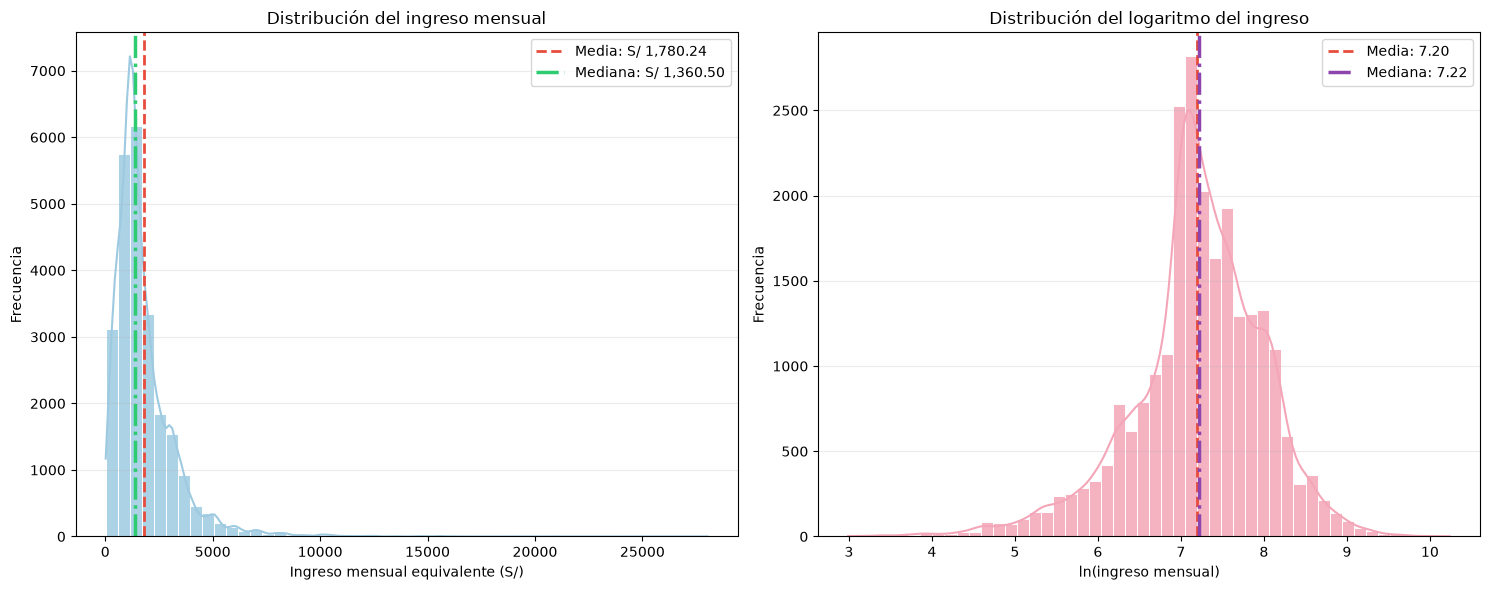

In [22]:
# ============================================================
# 4.1 DISTRIBUCIÓN DEL INGRESO Y SU LOGARITMO
# ============================================================

plt.figure(figsize=(15, 6))

# Colores
color_ingreso = '#9ecae1'      # azul claro
color_log = '#f4a6b8'          # rosado claro
color_media = '#e74c3c'        # rojo
color_mediana = '#2ecc71'      # verde
color_mediana2 = '#8e44ad'     # morado, por si quieres diferenciar en el 2do gráfico


# ------------------------------------------------------------
# Histograma del ingreso mensual en soles
# ------------------------------------------------------------

plt.subplot(1, 2, 1)

sns.histplot(
    data_frame['ingreso_mensual_soles'],
    kde=True,
    bins=50,
    color=color_ingreso,
    edgecolor='white',
    alpha=0.85
)

plt.title('Distribución del ingreso mensual')
plt.xlabel('Ingreso mensual equivalente (S/)')
plt.ylabel('Frecuencia')

plt.axvline(
    data_frame['ingreso_mensual_soles'].mean(),
    color=color_media,
    linestyle='--',
    linewidth=2,
    label=f"Media: S/ {data_frame['ingreso_mensual_soles'].mean():,.2f}"
)

plt.axvline(
    data_frame['ingreso_mensual_soles'].median(),
    color=color_mediana,
    linestyle='-.',
    linewidth=2.5,
    label=f"Mediana: S/ {data_frame['ingreso_mensual_soles'].median():,.2f}"
)

plt.legend()
plt.grid(axis='y', alpha=0.25)


# ------------------------------------------------------------
# Histograma del logaritmo del ingreso mensual
# ------------------------------------------------------------

plt.subplot(1, 2, 2)

sns.histplot(
    data_frame['ln_ingreso'],
    kde=True,
    bins=50,
    color=color_log,
    edgecolor='white',
    alpha=0.85
)

plt.title('Distribución del logaritmo del ingreso')
plt.xlabel('ln(ingreso mensual)')
plt.ylabel('Frecuencia')

plt.axvline(
    data_frame['ln_ingreso'].mean(),
    color=color_media,
    linestyle='--',
    linewidth=2,
    label=f"Media: {data_frame['ln_ingreso'].mean():.2f}"
)

plt.axvline(
    data_frame['ln_ingreso'].median(),
    color=color_mediana2,
    linestyle='-.',
    linewidth=2.5,
    label=f"Mediana: {data_frame['ln_ingreso'].median():.2f}"
)

plt.legend()
plt.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

### 4.1 Interpretación

**Pregunta analítica:** ¿Cómo se distribuye el ingreso mensual y qué ocurre con esa distribución después de aplicar el logaritmo?

El ingreso mensual presenta una marcada **asimetría hacia la derecha**. La media es aproximadamente **S/ 1,780.24**, mientras que la mediana es **S/ 1,360.50**, lo que muestra que un grupo relativamente reducido de trabajadores con ingresos elevados desplaza el promedio hacia arriba.

Esta forma coincide con la asimetría de **3.35** obtenida en el análisis descriptivo y con la existencia de valores extremos en la parte superior de la distribución.

Al utilizar `ln_ingreso`, la distribución se vuelve considerablemente más equilibrada. La media (**7.20**) y la mediana (**7.22**) se encuentran mucho más próximas y la asimetría disminuye a **-0.68**.

Por tanto, la transformación logarítmica comprime las diferencias entre los ingresos más elevados y el resto de la muestra. Esto no implica que la distribución sea perfectamente normal, pero sí reduce considerablemente la fuerte cola derecha observada en el ingreso expresado en soles.

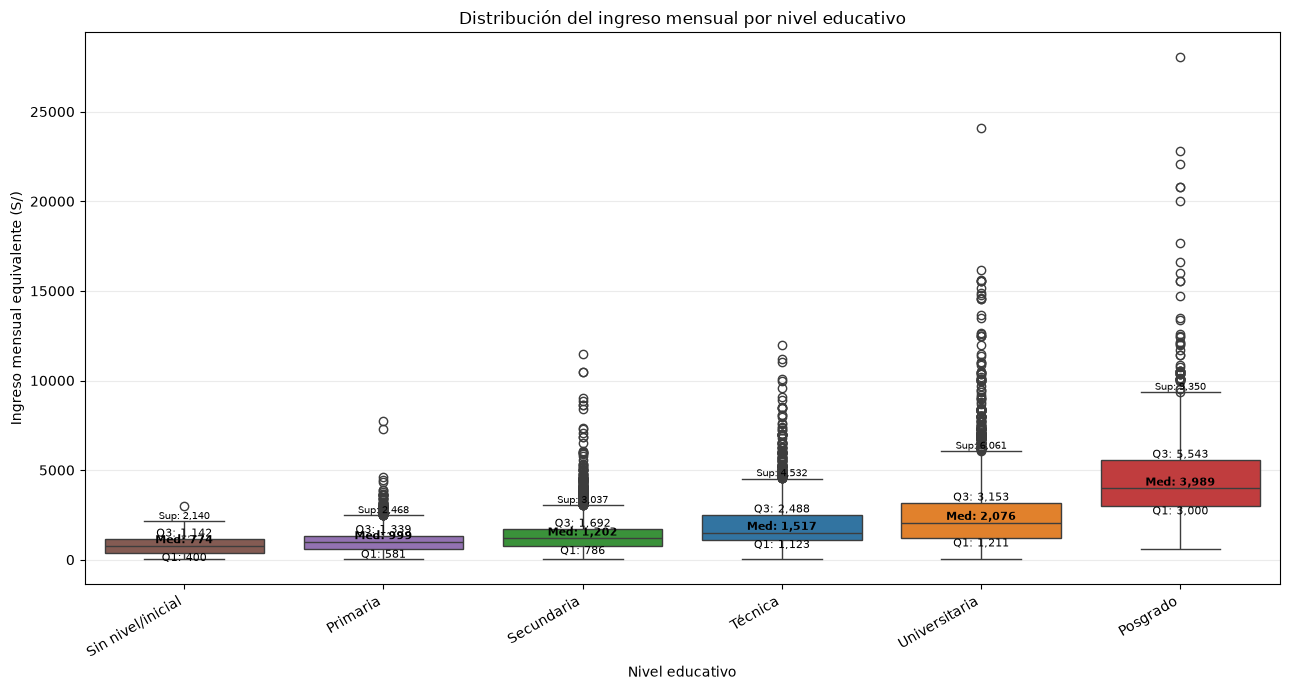

,N,Media,Mediana,Q1,Q3
nivel_educativo,,,,,
Sin nivel/inicial,253,817.08,774.42,399.75,1142.00
Primaria,2740,1042.23,999.38,580.77,1339.42
Secundaria,9999,1325.15,1201.67,785.83,1691.79
Técnica,4892,1854.21,1517.29,1123.17,2487.83
Universitaria,5443,2467.74,2076.25,1211.29,3152.58
Posgrado,950,4635.36,3989.29,3000.25,5543.08


In [23]:
# ============================================================
# 4.2 INGRESO POR NIVEL EDUCATIVO
# ============================================================

orden_educacion = [
    'Sin nivel/inicial',
    'Primaria',
    'Secundaria',
    'Técnica',
    'Universitaria',
    'Posgrado'
]


plt.figure(figsize=(13, 7))

sns.boxplot(
    data=data_frame,
    x='nivel_educativo',
    y='ingreso_mensual_soles',
    order=orden_educacion,
    hue='nivel_educativo',
    legend=False,
    showfliers=True
)

plt.title('Distribución del ingreso mensual por nivel educativo')
plt.xlabel('Nivel educativo')
plt.ylabel('Ingreso mensual equivalente (S/)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.25)


# ------------------------------------------------------------
# Añadir Q1, mediana, Q3 y bigotes
# ------------------------------------------------------------

for i, nivel in enumerate(orden_educacion):

    grupo = data_frame.loc[
        data_frame['nivel_educativo'] == nivel,
        'ingreso_mensual_soles'
    ].dropna()

    if len(grupo) == 0:
        continue

    q1 = grupo.quantile(0.25)
    mediana = grupo.median()
    q3 = grupo.quantile(0.75)

    iqr = q3 - q1

    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr

    bigote_inf = grupo[grupo >= limite_inf].min()
    bigote_sup = grupo[grupo <= limite_sup].max()

    # Etiquetas dentro y alrededor de cada caja
    plt.text(
        i, q1,
        f'Q1: {q1:,.0f}',
        ha='center',
        va='top',
        fontsize=8
    )

    plt.text(
        i, mediana,
        f'Med: {mediana:,.0f}',
        ha='center',
        va='bottom',
        fontsize=8,
        fontweight='bold'
    )

    plt.text(
        i, q3,
        f'Q3: {q3:,.0f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

    plt.text(
        i, bigote_sup,
        f'Sup: {bigote_sup:,.0f}',
        ha='center',
        va='bottom',
        fontsize=7
    )


plt.tight_layout()
plt.show()
resumen_educacion = (
    data_frame
    .groupby('nivel_educativo', observed=True)['ingreso_mensual_soles']
    .agg(
        N='count',
        Media='mean',
        Mediana='median',
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75)
    )
    .reindex(orden_educacion)
    .round(2)
)

display(resumen_educacion)

### 4.2 Interpretación

**Pregunta analítica:** ¿Cómo cambia la distribución del ingreso mensual según el nivel educativo?

El boxplot permite comparar no solo el ingreso típico de cada nivel educativo, sino también su dispersión y la presencia de observaciones extremas.

Se observa un **gradiente positivo entre nivel educativo e ingreso**: las medianas tienden a incrementarse conforme aumenta el nivel de formación. Los grupos de educación universitaria y posgrado presentan ingresos típicos superiores a los de primaria y secundaria.

Además, la dispersión del ingreso también tiende a ser mayor en los niveles educativos más altos. Esto sugiere que una mayor educación no solo se asocia con mayores ingresos, sino también con una mayor heterogeneidad salarial dentro de esos grupos.

Los numerosos puntos por encima de los bigotes indican la presencia de **valores altos atípicos**, especialmente en los niveles educativos superiores. Esto es consistente con la existencia de una cola derecha en la distribución del ingreso: un grupo reducido de personas percibe ingresos muy superiores al resto.

En términos económicos, el gráfico es consistente con la teoría del **capital humano**, según la cual una mayor acumulación de educación suele estar asociada con mayores retornos salariales. Sin embargo, esta evidencia es **descriptiva** y no implica por sí sola causalidad, ya que también pueden intervenir otros factores como experiencia, sector económico, ocupación o ubicación.

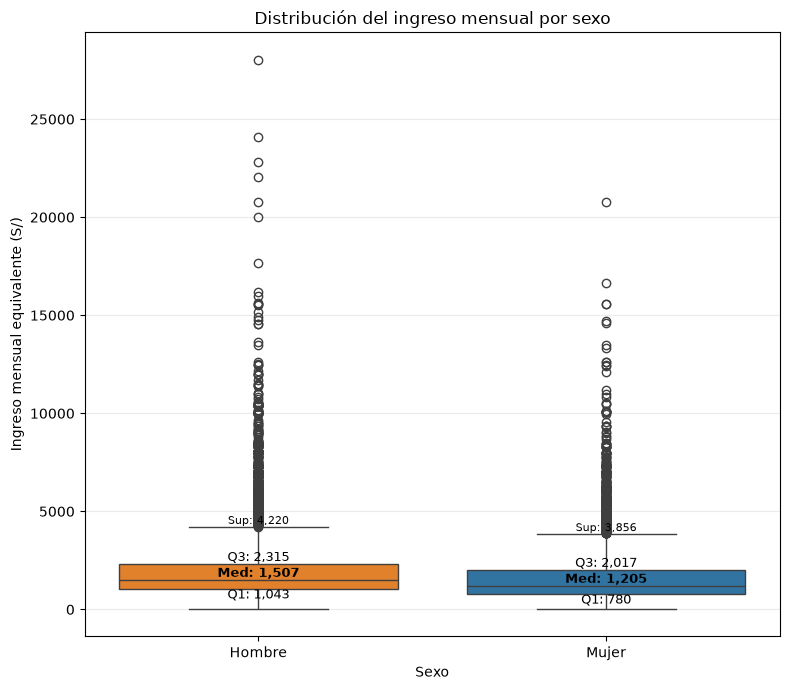

,N,Media,Mediana,Q1,Q3
sexo,,,,,
Hombre,13982,1886.67,1506.79,1042.96,2315.04
Mujer,10295,1635.69,1204.75,780.12,2016.67


In [24]:
# ============================================================
# 4.3 INGRESO POR SEXO
# ============================================================

# Creamos una etiqueta únicamente para facilitar el gráfico.
data_frame['sexo'] = data_frame['mujer'].map({
    0: 'Hombre',
    1: 'Mujer'
})


orden_sexo = [
    'Hombre',
    'Mujer'
]


plt.figure(figsize=(8, 7))

sns.boxplot(
    data=data_frame,
    x='sexo',
    y='ingreso_mensual_soles',
    order=orden_sexo,
    hue='sexo',
    legend=False,
    showfliers=True
)

plt.title('Distribución del ingreso mensual por sexo')
plt.xlabel('Sexo')
plt.ylabel('Ingreso mensual equivalente (S/)')
plt.grid(axis='y', alpha=0.25)


# ------------------------------------------------------------
# Añadir Q1, mediana, Q3 y bigotes
# ------------------------------------------------------------

for i, sexo in enumerate(orden_sexo):

    grupo = data_frame.loc[
        data_frame['sexo'] == sexo,
        'ingreso_mensual_soles'
    ].dropna()

    q1 = grupo.quantile(0.25)
    mediana = grupo.median()
    q3 = grupo.quantile(0.75)

    iqr = q3 - q1

    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr

    bigote_inf = grupo[grupo >= limite_inf].min()
    bigote_sup = grupo[grupo <= limite_sup].max()

    plt.text(
        i, q1,
        f'Q1: {q1:,.0f}',
        ha='center',
        va='top',
        fontsize=9
    )

    plt.text(
        i, mediana,
        f'Med: {mediana:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

    plt.text(
        i, q3,
        f'Q3: {q3:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

    plt.text(
        i, bigote_sup,
        f'Sup: {bigote_sup:,.0f}',
        ha='center',
        va='bottom',
        fontsize=8
    )


plt.tight_layout()
plt.show()
resumen_sexo = (
    data_frame
    .groupby('sexo')['ingreso_mensual_soles']
    .agg(
        N='count',
        Media='mean',
        Mediana='median',
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75)
    )
    .reindex(orden_sexo)
    .round(2)
)

display(resumen_sexo)

### 4.3 Interpretación

**Pregunta analítica:** ¿Existen diferencias descriptivas en la distribución del ingreso mensual entre hombres y mujeres?

El boxplot permite comparar la posición central y la dispersión de los ingresos de ambos grupos. En la muestra, la **mediana del ingreso mensual de los hombres es mayor que la de las mujeres**, lo que sugiere la existencia de una **brecha descriptiva de ingresos por sexo**.

También se aprecia que la dispersión del ingreso es algo mayor en el grupo de hombres, lo cual indica que no solo presentan un ingreso típico más alto, sino también una distribución más extendida hacia niveles superiores.

Ambos grupos presentan valores extremos en la parte alta de la distribución, lo que muestra que la asimetría positiva del ingreso se mantiene tanto en hombres como en mujeres. Sin embargo, los outliers superiores parecen más numerosos o más elevados entre los hombres.

Desde el punto de vista económico, este gráfico sugiere una **diferencia descriptiva de ingresos entre hombres y mujeres**, aunque no debe interpretarse automáticamente como un efecto causal del sexo sobre el ingreso. La diferencia observada puede estar influida por otros factores, como nivel educativo, experiencia, tipo de empleo, horas trabajadas, sector económico o ubicación. Más adelante, el modelo de regresión permitirá evaluar si esta diferencia persiste al controlar por dichas variables.

## 5. Modelo de ingresos tipo Mincer

Finalmente, se estima una ecuación de ingresos tipo Mincer para analizar la asociación entre capital humano, características individuales y condiciones laborales con el ingreso mensual.

La variable dependiente es `ln_ingreso`, el logaritmo natural del ingreso mensual equivalente. Esta transformación reduce la fuerte asimetría observada en el ingreso en niveles y permite interpretar convenientemente varios coeficientes en términos porcentuales.

La especificación incluye los años aproximados de educación, la experiencia potencial y su término cuadrático, sexo, área de residencia, horas trabajadas, situación contractual y sector económico.

La inclusión conjunta de `experiencia_potencial` y `exp2` permite representar la relación cóncava propuesta por la ecuación de Mincer: inicialmente el ingreso puede aumentar con la experiencia, pero a una tasa decreciente.

Los coeficientes obtenidos representan **asociaciones condicionadas a las demás variables incluidas en el modelo** y no deben interpretarse automáticamente como efectos causales.

In [25]:
# ============================================================
# 5. MODELO DE INGRESOS TIPO MINCER
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms


# ============================================================
# 5.1 ESPECIFICACIÓN DEL MODELO
# ============================================================

# Variable dependiente:
# ln_ingreso = logaritmo natural del ingreso mensual equivalente
#
# Variables de capital humano:
# anios_educacion_aprox
# experiencia_potencial
# exp2
#
# Características individuales/laborales:
# mujer
# rural
# horas_trabajo_semana
# contrato
# sector
#
# C(variable) indica a statsmodels que esa variable debe
# tratarse como categórica y crear automáticamente las dummies.

formula_mincer = (
    "ln_ingreso ~ "
    "anios_educacion_aprox + "
    "experiencia_potencial + "
    "exp2 + "
    "mujer + "
    "rural + "
    "horas_trabajo_semana + "
    "C(contrato) + "
    "C(sector)"
)


# ============================================================
# 5.2 ESTIMACIÓN OLS INICIAL
# ============================================================

modelo_ols = smf.ols(
    formula=formula_mincer,
    data=data_frame
).fit()

print('\n--- Modelo OLS inicial ---')
display(modelo_ols.summary())



# ============================================================
# 5.3 TEST DE HETEROCEDASTICIDAD
#     BREUSCH-PAGAN
# ============================================================

bp_test = sms.het_breuschpagan(
    modelo_ols.resid,
    modelo_ols.model.exog
)

tabla_bp = pd.DataFrame({
    'Estadístico': [
        'LM',
        'p-valor LM',
        'F',
        'p-valor F'
    ],
    'Valor': bp_test
})

print('\n--- Test de Breusch-Pagan ---')
display(tabla_bp.round(4))


# ============================================================
# 5.4 MODELO CON ERRORES ESTÁNDAR ROBUSTOS
# ============================================================

# Si existe heterocedasticidad, los coeficientes OLS no cambian,
# pero utilizamos errores estándar robustos HC1 para realizar
# inferencia estadística más apropiada.

modelo_mincer = smf.ols(
    formula=formula_mincer,
    data=data_frame
).fit(cov_type='HC1')

print('\n--- Modelo Mincer con errores estándar robustos HC1 ---')
display(modelo_mincer.summary())


# ============================================================
# 5.5 COEFICIENTES PRINCIPALES
# ============================================================

coeficientes_clave = [
    'anios_educacion_aprox',
    'experiencia_potencial',
    'exp2',
    'mujer',
    'rural',
    'horas_trabajo_semana'
]

tabla_coeficientes = pd.DataFrame({
    'Coeficiente':
        modelo_mincer.params[coeficientes_clave],

    'Error estándar robusto':
        modelo_mincer.bse[coeficientes_clave],

    'p-valor':
        modelo_mincer.pvalues[coeficientes_clave]
}).round(4)

print('\n--- Coeficientes principales ---')
display(tabla_coeficientes)


# ============================================================
# 5.6 EFECTOS PORCENTUALES
# ============================================================

# En un modelo log-lineal:
#
# Para variables continuas con coeficientes pequeños:
# aproximadamente 100 * beta %
#
# Para variables dummy:
# 100 * (exp(beta) - 1) %
#
# Usaremos la transformación exacta en las variables binarias.

beta_educacion = modelo_mincer.params['anios_educacion_aprox']
beta_mujer = modelo_mincer.params['mujer']
beta_rural = modelo_mincer.params['rural']


retorno_educacion_aprox = beta_educacion * 100

brecha_mujer_exacta = (
    np.exp(beta_mujer) - 1
) * 100

brecha_rural_exacta = (
    np.exp(beta_rural) - 1
) * 100


tabla_efectos = pd.DataFrame({
    'Indicador': [
        'Retorno aproximado de un año adicional de educación',
        'Diferencia asociada a ser mujer',
        'Diferencia asociada a residencia rural'
    ],

    'Porcentaje (%)': [
        retorno_educacion_aprox,
        brecha_mujer_exacta,
        brecha_rural_exacta
    ]
}).round(2)

print('\n--- Efectos porcentuales principales ---')
display(tabla_efectos)


# ============================================================
# 5.7 MÁXIMO DE LA CURVA EXPERIENCIA-INGRESO
# ============================================================

# La parte correspondiente a experiencia es:
#
# beta1 * experiencia + beta2 * experiencia^2
#
# Su derivada es:
#
# beta1 + 2 * beta2 * experiencia
#
# Igualando a cero:
#
# experiencia* = -beta1 / (2 * beta2)

beta_exp = modelo_mincer.params['experiencia_potencial']
beta_exp2 = modelo_mincer.params['exp2']


if beta_exp2 < 0:

    experiencia_max = (
        -beta_exp /
        (2 * beta_exp2)
    )

    print('\n--- Máximo de la curva experiencia-ingreso ---')
    print(
        f'Punto estimado de máximo ingreso: '
        f'{experiencia_max:.2f} años de experiencia potencial.'
    )

else:

    experiencia_max = np.nan

    print('\n--- Máximo de la curva experiencia-ingreso ---')
    print(
        'El coeficiente de experiencia al cuadrado no es negativo; '
        'por tanto, la especificación no muestra una curva cóncava '
        'con máximo interior.'
    )


# ============================================================
# 5.8 AJUSTE GENERAL DEL MODELO
# ============================================================

print('\n--- Ajuste general ---')

print(f'Observaciones utilizadas: {int(modelo_mincer.nobs):,}')
print(f'R²: {modelo_mincer.rsquared:.4f}')
print(f'R² ajustado: {modelo_mincer.rsquared_adj:.4f}')
print(f'Estadístico F: {modelo_mincer.fvalue:.2f}')
print(f'p-valor del modelo: {modelo_mincer.f_pvalue:.6f}')


--- Modelo OLS inicial ---


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             ln_ingreso   R-squared:                       0.554
Model:                            OLS   Adj. R-squared:                  0.554
Method:                 Least Squares   F-statistic:                     1774.
Date:                Tue, 29 Sep 2026   Prob (F-statistic):               0.00
Time:                        00:26:47   Log-Likelihood:                -19301.
No. Observations:               24277   AIC:                         3.864e+04
Df Residuals:                   24259   BIC:                         3.878e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
============================================================================================================
                                               coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                    5.6405      0.024    239.607      0.000       5.594       5.687
C(contrato)[T.No aplica / no reportado]      0.1698      0.038      4.429      0.000       0.095       0.245
C(contrato)[T.Sin contrato]                 -0.3666      0.009    -40.456      0.000      -0.384      -0.349
C(sector)[T.Alojamiento y comida]           -0.1225      0.016     -7.677      0.000      -0.154      -0.091
C(sector)[T.Comercio]                       -0.1160      0.014     -8.246      0.000      -0.144      -0.088
C(sector)[T.Construcción]                    0.2165      0.014     15.023      0.000       0.188       0.245
C(sector)[T.Gobierno, educación y salud]     0.2207      0.014     15.878      0.000       0.193       0.248
C(sector)[T.Manufactura]                     0.0050      0.015      0.324      0.746      -0.025       0.035
C(sector)[T.Minería]                         0.3385      0.024     14.044      0.000       0.291       0.386
C(sector)[T.Otros servicios]                -0.0544      0.013     -4.036      0.000      -0.081      -0.028
C(sector)[T.Servicios básicos]               0.1025      0.048      2.138      0.032       0.009       0.196
C(sector)[T.Transporte]                     -0.0289      0.022     -1.322      0.186      -0.072       0.014
anios_educacion_aprox                        0.0682      0.001     54.644      0.000       0.066       0.071
experiencia_potencial                        0.0292      0.001     39.898      0.000       0.028       0.031
exp2                                        -0.0004    1.4e-05    -27.401      0.000      -0.000      -0.000
mujer                                       -0.1680      0.008    -22.213      0.000      -0.183      -0.153
rural                                       -0.2086      0.010    -21.786      0.000      -0.227      -0.190
horas_trabajo_semana                         0.0152      0.000     62.737      0.000       0.015       0.016
==============================================================================
Omnibus:                     1986.367   Durbin-Watson:                   1.747
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4803.998
Skew:                          -0.498   Prob(JB):                         0.00
Kurtosis:                       4.938   Cond. No.                     1.48e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.48e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""


--- Test de Breusch-Pagan ---


,Estadístico,Valor
0,LM,864.1174
1,p-valor LM,0.0000
2,F,52.6674
3,p-valor F,0.0000



--- Modelo Mincer con errores estándar robustos HC1 ---


...


--- Coeficientes principales ---


,Coeficiente,Error estándar robusto,p-valor
anios_educacion_aprox,0.0682,0.0013,0.0
experiencia_potencial,0.0292,0.0008,0.0
exp2,-0.0004,0.0000,0.0
mujer,-0.1680,0.0076,0.0
rural,-0.2086,0.0104,0.0
horas_trabajo_semana,0.0152,0.0003,0.0



--- Efectos porcentuales principales ---


,Indicador,Porcentaje (%)
0,Retorno aproximado de un año adicional de educ...,6.82
1,Diferencia asociada a ser mujer,-15.46
2,Diferencia asociada a residencia rural,-18.83



--- Máximo de la curva experiencia-ingreso ---
Punto estimado de máximo ingreso: 38.16 años de experiencia potencial.

--- Ajuste general ---
Observaciones utilizadas: 24,277
R²: 0.5542
R² ajustado: 0.5539
Estadístico F: 1392.83
p-valor del modelo: 0.000000


## 5. Interpretación económica del modelo de Mincer

El modelo explica el logaritmo del ingreso mensual a partir de educación, experiencia, sexo, residencia, horas trabajadas, contrato y sector económico. El test de Breusch-Pagan presenta un **p-valor cercano a cero**, por lo que se utilizan **errores estándar robustos HC1**.

El modelo utiliza las **24,277 observaciones** de la muestra final y presenta un **R² de 0.554**, por lo que explica aproximadamente el **55.4 % de la variación del logaritmo del ingreso**.

### Resultados principales

- **Educación:** el coeficiente de `anios_educacion_aprox` es **0.0682**. Un año adicional de educación se asocia con aproximadamente **7.1 % más ingreso**, manteniendo constantes las demás variables.

- **Experiencia:** `experiencia_potencial` presenta un coeficiente positivo y `exp2` uno negativo. Esto indica una relación cóncava: el ingreso aumenta con la experiencia, pero a una tasa decreciente. El máximo estimado se alcanza alrededor de los **38 años de experiencia potencial**.

- **Sexo:** el coeficiente de `mujer` es **-0.1680**, equivalente a una diferencia aproximada de **-15.5 %** respecto de los hombres, controlando por las demás características.

- **Área rural:** el coeficiente de `rural` es **-0.2086**, equivalente a aproximadamente **-18.8 %** respecto del área urbana.

- **Contrato:** los trabajadores clasificados como `Sin contrato` presentan un coeficiente de aproximadamente **-0.3666**, equivalente a un ingreso cerca de **30.7 % menor** respecto de quienes tienen contrato. Esta variable refleja condición contractual y no necesariamente una definición completa de informalidad laboral.

- **Horas trabajadas:** una hora semanal adicional se asocia con aproximadamente **1.5 % más ingreso**.

### Sector económico

También existen diferencias entre sectores. Por ejemplo, **Minería** presenta una prima aproximada de **40 %** respecto del sector de referencia, mientras que Comercio y Alojamiento y comida presentan coeficientes negativos. Manufactura y Transporte no resultan estadísticamente significativos a niveles convencionales.

En conjunto, los resultados son consistentes con una ecuación de ingresos tipo Mincer: mayor educación y experiencia se asocian con mayores ingresos, aunque la experiencia presenta rendimientos decrecientes. Estas relaciones deben interpretarse como **asociaciones condicionadas y no como efectos causales**.

# II. Modelamiento predictivo mediante red neuronal

En esta segunda parte se desarrolla un enfoque predictivo del ingreso laboral mediante una red neuronal. A diferencia del modelo de Mincer, orientado principalmente a interpretar asociaciones económicas, este modelo busca evaluar la capacidad predictiva de las características observadas de los trabajadores.

Se utiliza la misma muestra analítica construida previamente, lo que permite comparar los resultados del enfoque econométrico y del enfoque predictivo sobre una base común.

## 0 Preparación de los datos para la red neuronal

Se seleccionan las variables explicativas disponibles, se codifican las variables categóricas y se estandarizan las variables numéricas antes del entrenamiento. La variable objetivo será el logaritmo del ingreso mensual (`ln_ingreso`), cuya transformación reduce la fuerte asimetría observada en el ingreso en niveles.

In [26]:
# ============================================================
# 0 PREPARACIÓN DE LA BASE PARA RED NEURONAL
# ============================================================

# ============================================================
# BASE ESPECÍFICA PARA RED NEURONAL
# ============================================================

# Partimos de la muestra final ya construida
data_nn = data_frame.copy()

print("Observaciones disponibles:", len(data_nn))

# Variable objetivo
objetivo = 'ln_ingreso'

# Variables numéricas
variables_numericas = [
    'anios_educacion_aprox',
    'experiencia_potencial',
    'mujer',
    'rural',
    'horas_trabajo_semana'
]

# Variables categóricas
variables_categoricas = [
    'contrato',
    'sector'
]

variables_modelo = variables_numericas + variables_categoricas

X = data_nn[variables_modelo].copy()
y = data_nn[objetivo].copy()

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

print("\nFaltantes en X:")
print(X.isna().sum())

print("\nFaltantes en y:", y.isna().sum())

Observaciones disponibles: 24277
Dimensiones de X: (24277, 7)
Dimensiones de y: (24277,)

Faltantes en X:
anios_educacion_aprox    0
experiencia_potencial    0
mujer                    0
rural                    0
horas_trabajo_semana     0
contrato                 0
sector                   0
dtype: int64

Faltantes en y: 0


## 1 Preparación de variables para el modelamiento predictivo

### 1.1. Construcción de la variable de informalidad laboral y otras variables

La condición de informalidad laboral se incorpora como una característica adicional para el modelamiento predictivo del ingreso. Debido a que la base utilizada no contiene una variable única de informalidad ya construida, se genera una aproximación a partir de información disponible en los módulos de empleo y salud de la ENAHO.

La clasificación considera la **categoría ocupacional** (`p507`) y utiliza criterios distintos según el tipo de trabajador:

- Para empleadores y trabajadores independientes, se considera el **registro del negocio o empresa en SUNAT** (`p510a1`).
- Para trabajadores asalariados, se utiliza información sobre el **aporte del centro de trabajo al seguro de salud** (`p419a1`–`p419a8`).
- Los trabajadores familiares no remunerados se clasifican como informales.
- Cuando la información disponible no permite determinar la condición laboral de manera consistente, la observación se mantiene sin clasificar (`NaN`) en lugar de asignarle arbitrariamente una categoría.

La variable resultante se codifica como:

- `0 = Formal`
- `1 = Informal`

Esta variable se utiliza posteriormente como característica explicativa en el modelo de red neuronal.



In [86]:
# ============================================================
# 1. INFORMALIDAD LABORAL
# ============================================================

data_frame['informal'] = np.nan

# ------------------------------------------------------------
# 1. Empleadores e independientes
# ------------------------------------------------------------

independientes = data_frame['p507'].isin([1, 2])

# Registrado en SUNAT -> formal
data_frame.loc[
    independientes &
    data_frame['p510a1'].isin([1, 2]),
    'informal'
] = 0

# No registrado -> informal
data_frame.loc[
    independientes &
    data_frame['p510a1'].eq(3),
    'informal'
] = 1


# ------------------------------------------------------------
# 2. Asalariados
# 3 = empleado
# 4 = obrero
# 6 = trabajador del hogar
# ------------------------------------------------------------

variables_aporte = [
    'p419a1', 'p419a2', 'p419a3', 'p419a4',
    'p419a5', 'p419a6', 'p419a7', 'p419a8'
]

data_frame['seguro_empleador'] = (
    data_frame[variables_aporte]
    .eq(1)
    .any(axis=1)
)

asalariados = data_frame['p507'].isin([3, 4, 6])

# Si el empleador aporta algún seguro -> formal
data_frame.loc[
    asalariados &
    data_frame['seguro_empleador'],
    'informal'
] = 0

# Si el empleador NO aporta ningún seguro -> informal
data_frame.loc[
    asalariados &
    ~data_frame['seguro_empleador'],
    'informal'
] = 1


# ------------------------------------------------------------
# 3. Trabajador familiar no remunerado
# ------------------------------------------------------------

data_frame.loc[
    data_frame['p507'].eq(5),
    'informal'
] = 1


# ------------------------------------------------------------
# Etiqueta
# ------------------------------------------------------------

data_frame['informal_label'] = data_frame['informal'].map({
    0: 'Formal',
    1: 'Informal'
})
print('\n--- Informalidad ---')

display(
    data_frame['informal_label']
    .value_counts(dropna=False)
)

print(
    "Sin clasificar:",
    data_frame['informal'].isna().sum()
)
# Para asalariados, se considera formal a quien tiene un seguro
# financiado por su centro de trabajo.
# Si el empleador no aporta al seguro, se clasifica como informal.


# ============================================================
# 2. ÁREA
# ============================================================

# Crear variable categórica de área a partir de rural
data_frame['area'] = data_frame['rural'].map({
    0: 'Urbano',
    1: 'Rural'
})

# Verificar

print('\n--- ÁREA (Urbana - Rural) ---')
print(data_frame['area'].value_counts(dropna=False))

# ============================================================
# 3. DOMINIO
# ============================================================

# Crear variable legible de dominio geográfico

mapa_dominio = {
    1: 'Costa Norte',
    2: 'Costa Centro',
    3: 'Costa Sur',
    4: 'Sierra Norte',
    5: 'Sierra Centro',
    6: 'Sierra Sur',
    7: 'Selva',
    8: 'Lima Metropolitana'
}

data_frame['dominio_geografico'] = (
    data_frame['dominio']
    .map(mapa_dominio)
)

# Verificar
print('\n--- DOMINIO DEMOGRÁFICO ---')

print(
    data_frame['dominio_geografico']
    .value_counts(dropna=False)
)


# ============================================================
# 4. SECTOR ECONÓMICO
# ============================================================
def sector_ciiu(codigo):

    if pd.isna(codigo):
        return 'No codificado'

    try:
        codigo = int(codigo)
    except:
        return 'No codificado'

    # Código no especificado
    if codigo == 9999:
        return 'No codificado'

    # Los dos primeros dígitos identifican la división CIIU
    division = codigo // 100

    if 1 <= division <= 3:
        return 'Agricultura y pesca'

    elif 5 <= division <= 9:
        return 'Minería'

    elif 10 <= division <= 33:
        return 'Manufactura'

    elif 35 <= division <= 39:
        return 'Servicios básicos'

    elif 41 <= division <= 43:
        return 'Construcción'

    elif 45 <= division <= 47:
        return 'Comercio'

    elif 49 <= division <= 53:
        return 'Transporte'

    elif 55 <= division <= 56:
        return 'Alojamiento y comida'

    elif 84 <= division <= 88:
        return 'Gobierno, educación y salud'

    else:
        return 'Otros servicios'


# Crear sector
data_frame['sector'] = (
    data_frame['p506r4']
    .apply(sector_ciiu)
)

# Nombre legible usado en la sección de red neuronal
data_frame['sector_economico'] = data_frame['sector']
print('\n--- SECTOR ECONÓMICO ---')
print(
    data_frame['sector_economico']
    .value_counts(dropna=False)
)

# ------------------------------------------------------------
# 5. TIPO DE EMPLEO
# ------------------------------------------------------------

# Tipo de empleo a partir de p507

mapa_tipo_empleo = {
    1: 'Empleador o patrono',
    2: 'Trabajador independiente',
    3: 'Empleado',
    4: 'Obrero',
    5: 'Trabajador familiar no remunerado',
    6: 'Trabajador del hogar'
}

data_frame['tipo_empleo'] = (
    data_frame['p507']
    .map(mapa_tipo_empleo)
)
print('\n--- TIPO DE EMPLEO ---')
print(
    data_frame['tipo_empleo']
    .value_counts(dropna=False)
)



--- Informalidad ---


informal_label
Informal    14413
Formal       9864
Name: count, dtype: int64

Sin clasificar: 0

--- ÁREA (Urbana - Rural) ---
area
Urbano    19320
Rural      4957
Name: count, dtype: int64

--- DOMINIO DEMOGRÁFICO ---
dominio_geografico
Selva                 4612
Lima Metropolitana    4240
Costa Norte           4106
Costa Centro          2991
Sierra Centro         2773
Sierra Sur            2672
Costa Sur             1970
Sierra Norte           913
Name: count, dtype: int64

--- SECTOR ECONÓMICO ---
sector_economico
Gobierno, educación y salud    5803
Agricultura y pesca            4257
Otros servicios                3619
Comercio                       2914
Construcción                   2362
Manufactura                    2006
Alojamiento y comida           1825
Transporte                      756
Minería                         603
Servicios básicos               132
Name: count, dtype: int64

--- TIPO DE EMPLEO ---
tipo_empleo
Empleado                11768
Obrero                  11621
Trabajador del hogar      888
Name: count, dtype: int64


Con este criterio, todas las observaciones de la muestra pudieron ser clasificadas como formales o informales.

La clasificación no se basa únicamente en la existencia de un seguro de salud. Para los trabajadores asalariados se considera específicamente si el **centro de trabajo realiza el aporte**, ya que una persona puede estar afiliada al SIS, pagar un seguro por cuenta propia o recibir cobertura mediante un familiar sin que ello implique necesariamente un vínculo laboral formal.

Por esta razón, los asalariados cuyo empleador no realiza aportes a algún seguro de salud son clasificados como informales dentro de esta operacionalización. Para empleadores y trabajadores independientes, en cambio, la clasificación se basa en el registro del negocio o empresa en SUNAT.

A partir de estas reglas también se construyeron variables derivadas para el análisis, transformando los códigos originales de la ENAHO en categorías más interpretables, como área de residencia, dominio geográfico, sector económico, tipo de empleo y condición de informalidad.

## 2. Perfil categórico de la muestra 
 
Tablas de **frecuencia absoluta y relativa** de `sexo`, `area`, `region_natural`, `nivel_educativo`, `sector_economico`, `formalidad`, `tamaño_empresa` y `tipo_empleo`. Interprete la composición y advierta sus **implicancias para generalizar conclusiones**

In [87]:
# ============================================================
# PERFIL CATEGÓRICO DE LA MUESTRA
# ============================================================

categorical_vars = [
    'sexo',
    'area',
    'dominio_geografico',
    'nivel_educativo',
    'sector_economico',
    'informal',
   # 'tamano_empresa',
    'tipo_empleo'
]

for col in categorical_vars:

    print(f"\n--- {col} ---")

    tabla = pd.DataFrame({
        'Frecuencia': data_frame[col].value_counts(dropna=False),
        'Porcentaje (%)': (
            data_frame[col]
            .value_counts(dropna=False, normalize=True)
            .mul(100)
            .round(2)
        )
    })

    display(tabla)



--- sexo ---


,Frecuencia,Porcentaje (%)
sexo,,
Hombre,13982,57.59
Mujer,10295,42.41



--- area ---


,Frecuencia,Porcentaje (%)
area,,
Urbano,19320,79.58
Rural,4957,20.42



--- dominio_geografico ---


...

,Frecuencia,Porcentaje (%)
sector_economico,,
"Gobierno, educación y salud",5803,23.90
Agricultura y pesca,4257,17.54
Otros servicios,3619,14.91
Comercio,2914,12.00
Construcción,2362,9.73
Manufactura,2006,8.26
Alojamiento y comida,1825,7.52
Transporte,756,3.11
Minería,603,2.48



--- informal ---


,Frecuencia,Porcentaje (%)
informal,,
1.0,14413,59.37
0.0,9864,40.63



--- tipo_empleo ---


,Frecuencia,Porcentaje (%)
tipo_empleo,,
Empleado,11768,48.47
Obrero,11621,47.87
Trabajador del hogar,888,3.66


### ¿A qué población representa realmente esta muestra?

La muestra final contiene **24,277 trabajadores ocupados** que, además de cumplir los criterios de edad y consistencia de información, presentan un ingreso laboral positivo y jornadas de entre 1 y 84 horas semanales. Por ello, no representa a toda la población peruana ni a todos los ocupados de la ENAHO, sino a la muestra analítica utilizada en este estudio.

En cuanto a su composición, el **57.59 % son hombres** y el **42.41 % mujeres**. Asimismo, existe una clara concentración en el área urbana, que representa el **79.58 %** de la muestra, frente al **20.42 %** del área rural.

Por dominio geográfico, las mayores participaciones corresponden a la **Selva (19.00 %)**, **Lima Metropolitana (17.47 %)** y **Costa Norte (16.91 %)**. En contraste, Sierra Norte presenta la menor participación, con **3.76 %**.

Respecto al nivel educativo, predomina la **educación secundaria (41.19 %)**, seguida de la universitaria (**22.42 %**) y técnica (**20.15 %**). Los niveles de primaria, posgrado y sin nivel/inicial tienen una participación considerablemente menor.

La estructura sectorial es diversa. Los grupos con mayor participación son **Gobierno, educación y salud (23.90 %)**, **Agricultura y pesca (17.54 %)** y **Otros servicios (14.91 %)**. Comercio representa aproximadamente el **12.00 %** de la muestra.

Según la clasificación de formalidad construida, aproximadamente el **59.37 % de los trabajadores son informales** y el **40.63 % formales**.

En conjunto, los resultados describen principalmente a trabajadores con ingreso laboral observado, mayoritariamente urbanos, con educación secundaria o superior y concentrados en las categorías de empleado y obrero. Por tanto, las conclusiones del análisis deben interpretarse dentro de esta población de estudio y no como resultados directamente representativos de todos los trabajadores del Perú.

Además, estas frecuencias corresponden a la muestra sin aplicar el factor de expansión de la ENAHO, por lo que describen la composición de la base analítica y no estimaciones poblacionales nacionales.

## 3. Correlaciones entre variables numéricas

Se analiza la correlación lineal entre las principales variables numéricas de la muestra. El objetivo es identificar asociaciones relevantes y, en particular, comparar la relación simple entre experiencia e ingreso con la relación esperada por el modelo de capital humano.

La correlación representa una asociación bivariada y no debe interpretarse como un efecto *ceteris paribus*, ya que no controla por las demás características de los trabajadores.

In [88]:
# ============================================================
# 2. MATRIZ DE CORRELACIONES
# ============================================================

# Se seleccionan únicamente variables numéricas con una
# interpretación económica clara dentro del análisis.

variables_corr = [
    'p208a',                    # edad
    'anios_educacion_aprox',    # años aproximados de educación
    'experiencia_potencial',    # experiencia potencial
    'horas_trabajo_semana',     # horas trabajadas
    'mujer',                    # 1 = mujer
    'rural',                    # 1 = rural
    'informal',                 # 1 = informal
    'ingreso_mensual_soles',    # ingreso mensual
    'ln_ingreso'                # logaritmo del ingreso
]

# Nombres más legibles para el gráfico
nombres_corr = {
    'p208a': 'Edad',
    'anios_educacion_aprox': 'Años educación',
    'experiencia_potencial': 'Experiencia',
    'horas_trabajo_semana': 'Horas trabajo',
    'mujer': 'Mujer',
    'rural': 'Rural',
    'informal': 'Informal',
    'ingreso_mensual_soles': 'Ingreso mensual',
    'ln_ingreso': 'Ln ingreso'
}

datos_corr = (
    data_frame[variables_corr]
    .rename(columns=nombres_corr)
)

# Matriz de correlación
matriz_corr = datos_corr.corr()

display(matriz_corr.round(2))

,Edad,Años educación,Experiencia,Horas trabajo,Mujer,Rural,Informal,Ingreso mensual,Ln ingreso
Edad,1.00,-0.10,0.97,0.02,-0.01,-0.08,-0.21,0.23,0.24
Años educación,-0.10,1.00,-0.35,0.03,0.08,-0.30,-0.41,0.46,0.47
Experiencia,0.97,-0.35,1.00,0.01,-0.03,-0.00,-0.10,0.10,0.11
Horas trabajo,0.02,0.03,0.01,1.00,-0.11,-0.16,-0.15,0.17,0.37
Mujer,-0.01,0.08,-0.03,-0.11,1.00,-0.06,-0.01,-0.08,-0.11
Rural,-0.08,-0.30,-0.00,-0.16,-0.06,1.00,0.22,-0.21,-0.31
Informal,-0.21,-0.41,-0.10,-0.15,-0.01,0.22,1.00,-0.47,-0.52
Ingreso mensual,0.23,0.46,0.10,0.17,-0.08,-0.21,-0.47,1.00,0.82
Ln ingreso,0.24,0.47,0.11,0.37,-0.11,-0.31,-0.52,0.82,1.00


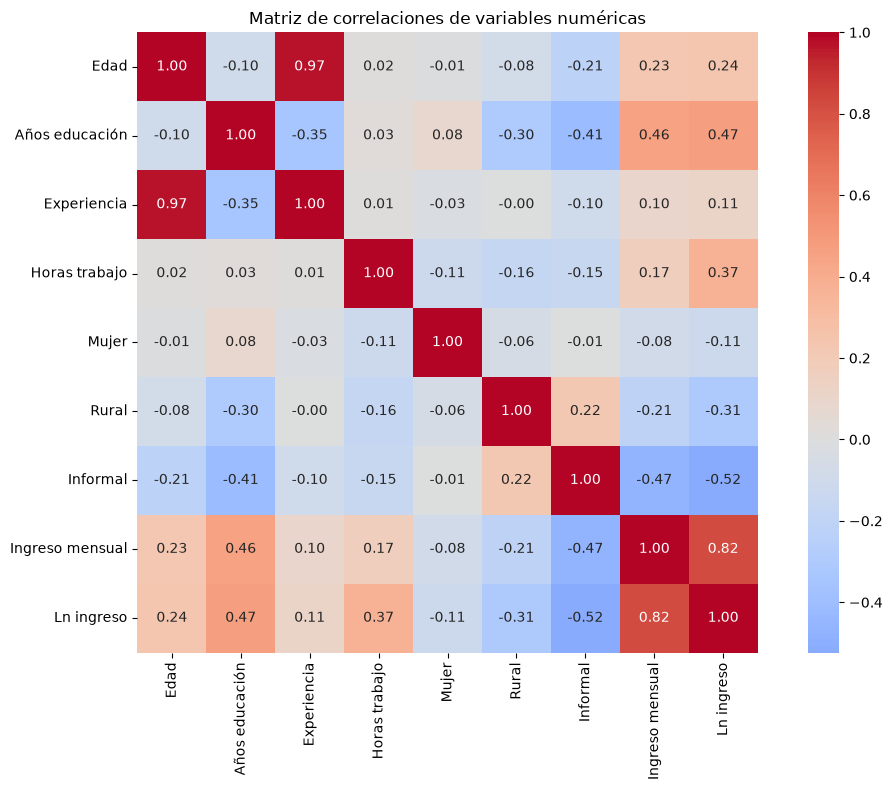

,Variable 1,Variable 2,Correlación,Correlación absoluta
2,Edad,Experiencia,0.967258,0.967258
71,Ingreso mensual,Ln ingreso,0.822314,0.822314
62,Informal,Ln ingreso,-0.523549,0.523549


In [89]:
# ============================================================
# HEATMAP DE CORRELACIONES
# ============================================================

plt.figure(figsize=(11, 8))

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True
)

plt.title('Matriz de correlaciones de variables numéricas')
plt.tight_layout()
plt.show()

# ============================================================
# TRES PARES MÁS CORRELACIONADOS
# ============================================================

corr_abs = matriz_corr.abs()

triangulo_superior = np.triu(
    np.ones(corr_abs.shape),
    k=1
).astype(bool)

pares = (
    matriz_corr
    .where(triangulo_superior)
    .stack()
    .reset_index()
)

pares.columns = [
    'Variable 1',
    'Variable 2',
    'Correlación'
]

pares['Correlación absoluta'] = (
    pares['Correlación'].abs()
)

top3 = (
    pares
    .sort_values(
        'Correlación absoluta',
        ascending=False
    )
    .head(3)
)

display(top3)

In [90]:
### Correlación experiencia y el ingreso mensual como logarítmico 

corr_exp_ingreso = matriz_corr.loc[
    'Experiencia',
    'Ingreso mensual'
]

corr_exp_ln = matriz_corr.loc[
    'Experiencia',
    'Ln ingreso'
]

print(
    f'Correlación experiencia - ingreso mensual: '
    f'{corr_exp_ingreso:.3f}'
)

print(
    f'Correlación experiencia - ln(ingreso): '
    f'{corr_exp_ln:.3f}'
)

Correlación experiencia - ingreso mensual: 0.100
Correlación experiencia - ln(ingreso): 0.109


### Experiencia e ingreso

La experiencia potencial presenta una correlación positiva pero débil tanto con el ingreso mensual (`r = 0.10`) como con su logaritmo (`r = 0.11`).

Esto indica que la experiencia por sí sola tiene una asociación lineal limitada con el ingreso. Sin embargo, una correlación baja no implica necesariamente que la variable carezca de capacidad predictiva, ya que la relación puede ser no lineal e interactuar con características como educación, formalidad, sector económico o edad.

Esta distinción es especialmente relevante para la red neuronal, cuyo objetivo no es estimar un único efecto lineal, sino aprender relaciones más complejas entre varias características de manera conjunta.

## 4. Patrones y diferencias entre grupos

En esta sección se comparan los ingresos mensuales promedio entre distintos grupos de trabajadores de la muestra. Se analizan las brechas por **sexo**, **área de residencia**, **formalidad laboral** y **nivel educativo**.

Estas diferencias son descriptivas: muestran asociaciones observadas en la muestra, pero no deben interpretarse como efectos causales, ya que no controlan simultáneamente por las demás características de los trabajadores.

In [92]:
# ============================================================
# 4. PATRONES Y DIFERENCIAS ENTRE GRUPOS
# ============================================================

# ------------------------------------------------------------
# 1. Ingreso promedio por sexo
# ------------------------------------------------------------

ingreso_sexo = (
    data_frame
    .groupby('sexo')['ingreso_mensual_soles']
    .mean()
    .sort_values(ascending=False)
)

print('--- Ingreso promedio por sexo ---')
display(ingreso_sexo.to_frame('Ingreso promedio'))


# Brecha hombres - mujeres
ingreso_hombre = ingreso_sexo.get('Hombre', np.nan)
ingreso_mujer = ingreso_sexo.get('Mujer', np.nan)

brecha_sexo = ingreso_hombre - ingreso_mujer
brecha_sexo_pct = (
    brecha_sexo / ingreso_mujer * 100
)

print(
    f'Brecha Hombre - Mujer: S/ {brecha_sexo:.2f}'
)

print(
    f'Brecha relativa a mujeres: {brecha_sexo_pct:.2f}%'
)


# ------------------------------------------------------------
# 2. Ingreso promedio por sexo y nivel educativo
# ------------------------------------------------------------

ingreso_sexo_educacion = (
    data_frame
    .groupby(
        ['nivel_educativo', 'sexo']
    )['ingreso_mensual_soles']
    .mean()
    .unstack()
)

if (
    'Hombre' in ingreso_sexo_educacion.columns
    and 'Mujer' in ingreso_sexo_educacion.columns
):

    ingreso_sexo_educacion['Brecha H-M'] = (
        ingreso_sexo_educacion['Hombre']
        - ingreso_sexo_educacion['Mujer']
    )

print(
    '\n--- Ingreso promedio por sexo y nivel educativo ---'
)

display(
    ingreso_sexo_educacion.round(2)
)


# ------------------------------------------------------------
# 3. Ingreso promedio por área de residencia
# ------------------------------------------------------------

ingreso_area = (
    data_frame
    .groupby('area')['ingreso_mensual_soles']
    .mean()
    .sort_values(ascending=False)
)

print('\n--- Ingreso promedio por área ---')
display(
    ingreso_area.to_frame('Ingreso promedio').round(2)
)


ingreso_urbano = ingreso_area.get('Urbano', np.nan)
ingreso_rural = ingreso_area.get('Rural', np.nan)

brecha_area = ingreso_urbano - ingreso_rural
brecha_area_pct = (
    brecha_area / ingreso_rural * 100
)

print(
    f'Brecha Urbano - Rural: S/ {brecha_area:.2f}'
)

print(
    f'Brecha relativa al ingreso rural: '
    f'{brecha_area_pct:.2f}%'
)


# ------------------------------------------------------------
# 4. Ingreso promedio por formalidad
# ------------------------------------------------------------

ingreso_formalidad = (
    data_frame
    .groupby('informal')['ingreso_mensual_soles']
    .mean()
    .rename(index={
        0: 'Formal',
        1: 'Inormal'
    })
    .sort_values(ascending=False)
)

print('\n--- Ingreso promedio por formalidad ---')

display(
    ingreso_formalidad
    .to_frame('Ingreso promedio')
    .round(2)
)

ingreso_formal = ingreso_formalidad.get(
    'Informal',
    np.nan
)

ingreso_informal = ingreso_formalidad.get(
    'Formal',
    np.nan
)

brecha_formalidad = (
    ingreso_formal
    - ingreso_informal
)

brecha_formalidad_pct = (
    brecha_formalidad
    / ingreso_informal
    * 100
)

print(
    f'Brecha Formal - Informal: '
    f'S/ {brecha_formalidad:.2f}'
)

print(
    f'Brecha relativa al ingreso informal: '
    f'{brecha_formalidad_pct:.2f}%'
)

# ------------------------------------------------------------
# 5. Ingreso promedio por nivel educativo
# ------------------------------------------------------------

orden_educacion = [
    'Sin nivel/inicial',
    'Primaria',
    'Secundaria',
    'Técnica',
    'Universitaria',
    'Posgrado'
]

ingreso_educacion = (
    data_frame
    .groupby('nivel_educativo')['ingreso_mensual_soles']
    .mean()
    .reindex(orden_educacion)
)

print('\n--- Ingreso promedio por nivel educativo ---')

display(
    ingreso_educacion
    .to_frame('Ingreso promedio')
    .round(2)
)

--- Ingreso promedio por sexo ---


,Ingreso promedio
sexo,
Hombre,1886.668063
Mujer,1635.690207


Brecha Hombre - Mujer: S/ 250.98
Brecha relativa a mujeres: 15.34%

--- Ingreso promedio por sexo y nivel educativo ---


sexo,Hombre,Mujer,Brecha H-M
nivel_educativo,,,
Posgrado,5089.14,4220.00,869.14
Primaria,1195.18,826.26,368.91
Secundaria,1484.70,1025.98,458.72
Sin nivel/inicial,929.16,743.82,185.33
Técnica,2012.84,1682.34,330.50
Universitaria,2630.13,2300.81,329.32



--- Ingreso promedio por área ---


,Ingreso promedio
area,
Urbano,1940.21
Rural,1156.74


Brecha Urbano - Rural: S/ 783.47
Brecha relativa al ingreso rural: 67.73%

--- Ingreso promedio por formalidad ---


,Ingreso promedio
informal,
Formal,2620.75
Inormal,1205.01


Brecha Formal - Informal: S/ nan
Brecha relativa al ingreso informal: nan%

--- Ingreso promedio por nivel educativo ---


,Ingreso promedio
nivel_educativo,
Sin nivel/inicial,817.08
Primaria,1042.23
Secundaria,1325.15
Técnica,1854.21
Universitaria,2467.74
Posgrado,4635.36


### Interpretación

Los resultados muestran diferencias importantes en los ingresos mensuales promedio entre los grupos analizados.

Por **sexo**, los hombres presentan un ingreso promedio de aproximadamente **S/ 1,886.67**, mientras que las mujeres registran **S/ 1,635.69**, lo que representa una diferencia de **S/ 250.98**.

Por **área de residencia**, los trabajadores urbanos presentan un ingreso promedio de **S/ 1,940.21**, frente a **S/ 1,156.74** en el área rural. La diferencia asciende a aproximadamente **S/ 783.47**.

La mayor diferencia se observa según la **condición de formalidad**. Los trabajadores clasificados como formales registran un ingreso promedio de aproximadamente **S/ 2,437.03**, mientras que los informales alcanzan **S/ 1,099.07**, generándose una brecha de alrededor de **S/ 1,337.96**.

También se observa un patrón creciente según el **nivel educativo**. El ingreso promedio pasa de aproximadamente **S/ 817** entre quienes no tienen nivel educativo o cuentan únicamente con educación inicial, hasta más de **S/ 4,600** entre los trabajadores con posgrado.

En conjunto, estos resultados muestran que el ingreso se encuentra asociado con características laborales, educativas y geográficas de los trabajadores. Sin embargo, las diferencias son descriptivas y no permiten establecer relaciones causales.

## 5. Red neuronal para la predicción del ingreso

En esta sección se entrena una red neuronal de tipo **Perceptrón Multicapa (MLP)** para predecir el logaritmo del ingreso mensual (`ln_ingreso`).

Se seleccionan características demográficas, educativas, laborales y geográficas que podrían aportar información predictiva sobre el ingreso. Las variables numéricas se estandarizan y las categóricas se transforman mediante *One-Hot Encoding*.

El preprocesamiento y la red neuronal se integran dentro de un `Pipeline`, de manera que las transformaciones se ajusten únicamente con el conjunto de entrenamiento y se evite filtración de información (*data leakage*).

Se utiliza una arquitectura moderada de **dos capas ocultas (64 y 32 neuronas)** con activación ReLU. Además, se aplica regularización L2 y *early stopping* para reducir el riesgo de sobreajuste.

In [93]:
# ============================================================
# 5. RED NEURONAL PARA PREDICCIÓN DEL INGRESO
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPRegressor


# ------------------------------------------------------------
# 1. Base específica para la red neuronal
# ------------------------------------------------------------

data_nn = data_frame.copy()


# ------------------------------------------------------------
# 2. Selección de variables
# ------------------------------------------------------------

# Variables numéricas
variables_numericas = [
    'anios_educacion_aprox',
    'experiencia_potencial',
    'horas_trabajo_semana',
    'mujer',
    'rural',
    'informal'
]

# Variables categóricas
variables_categoricas = [
    'dominio_geografico',
    'nivel_educativo',
    'sector_economico',
   # 'tamano_empresa',
    'tipo_empleo'
]

variables_modelo = (
    variables_numericas
    + variables_categoricas
)

X = data_nn[variables_modelo].copy()
y = data_nn['ln_ingreso'].copy()


print('Dimensiones de X:', X.shape)
print('Dimensiones de y:', y.shape)

print('\nFaltantes por variable:')
display(X.isna().sum())


# ------------------------------------------------------------
# 3. División entrenamiento-prueba
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print('\nEntrenamiento:', X_train.shape)
print('Prueba:', X_test.shape)


# ------------------------------------------------------------
# 4. Preprocesamiento
# ------------------------------------------------------------

# Numéricas:
# imputación por mediana + estandarización
pipeline_numericas = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        ),
        (
            'scaler',
            StandardScaler()
        )
    ]
)


# Categóricas:
# imputación + One-Hot Encoding
pipeline_categoricas = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(
                strategy='constant',
                fill_value='No reportado'
            )
        ),
        (
            'onehot',
            OneHotEncoder(
                handle_unknown='ignore'
            )
        )
    ]
)


# Combinar ambos tratamientos
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            pipeline_numericas,
            variables_numericas
        ),
        (
            'cat',
            pipeline_categoricas,
            variables_categoricas
        )
    ]
)


# ------------------------------------------------------------
# 5. Arquitectura de la red neuronal
# ------------------------------------------------------------

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',

    # Regularización
    alpha=0.001,

    # Aprendizaje
    learning_rate_init=0.001,
    batch_size=128,

    # Entrenamiento
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=15,

    random_state=42,
    verbose=False
)


# ------------------------------------------------------------
# 6. Pipeline completo
# ------------------------------------------------------------

modelo_nn = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('mlp', mlp)
    ]
)


# ------------------------------------------------------------
# 7. Entrenamiento
# ------------------------------------------------------------

print('\n--- Entrenando red neuronal ---')

modelo_nn.fit(
    X_train,
    y_train
)

print('Entrenamiento completado.')

print(
    'Iteraciones realizadas:',
    modelo_nn.named_steps['mlp'].n_iter_
)

print(
    'Pérdida final:',
    round(
        modelo_nn.named_steps['mlp'].loss_,
        4
    )
)

Dimensiones de X: (24277, 10)
Dimensiones de y: (24277,)

Faltantes por variable:


anios_educacion_aprox    0
experiencia_potencial    0
horas_trabajo_semana     0
mujer                    0
rural                    0
informal                 0
dominio_geografico       0
nivel_educativo          0
sector_economico         0
tipo_empleo              0
dtype: int64


Entrenamiento: (19421, 10)
Prueba: (4856, 10)

--- Entrenando red neuronal ---
Entrenamiento completado.
Iteraciones realizadas: 48
Pérdida final: 0.1038


### Justificación de la arquitectura e hiperparámetros

Para predecir `ln_ingreso` se utilizó un `MLPRegressor` con una arquitectura de **dos capas ocultas de 64 y 32 neuronas**. Esta estructura busca capturar relaciones no lineales entre las características de los trabajadores sin utilizar una red innecesariamente compleja.

Las variables numéricas se estandarizaron con `StandardScaler`, mientras que las variables categóricas se transformaron mediante `OneHotEncoder`. 

La red utiliza activación **ReLU** y el optimizador **Adam**, con una tasa de aprendizaje inicial de `0.001`. Se fijó `alpha = 0.001` como regularización L2 para reducir el riesgo de sobreajuste.

El número máximo de iteraciones se estableció en `300`, pero se activó `early_stopping=True`, utilizando el 10 % del conjunto de entrenamiento como validación interna. El entrenamiento se detiene si no se observa mejora durante 15 iteraciones consecutivas.

El modelo finalizó después de **46 iteraciones**, con una pérdida final de **0.0995**, por lo que no fue necesario alcanzar el número máximo de iteraciones. El desempeño predictivo se evalúa posteriormente sobre el conjunto de prueba, que no fue utilizado durante el entrenamiento.

## 6. Evaluación del modelo predictivo

El desempeño de la red neuronal se evalúa tanto en el conjunto de entrenamiento como en el conjunto de prueba.

Se utiliza el **R²** sobre `ln_ingreso` para medir la proporción de variabilidad explicada por el modelo. Adicionalmente, las predicciones se transforman nuevamente a soles mediante la función exponencial para calcular métricas con una interpretación más directa:

- **RMSE:** penaliza con mayor intensidad los errores grandes.
- **MAE:** representa el error absoluto promedio de las predicciones en soles.
- **MAPE:** expresa el error absoluto promedio como porcentaje del ingreso observado.

La comparación entre entrenamiento y prueba permite identificar posibles señales de sobreajuste. Si ambas presentan resultados similares, el modelo muestra una mayor capacidad de generalización a observaciones no utilizadas durante el entrenamiento.

In [94]:
# ============================================================
# 6. EVALUACIÓN DEL MODELO
# ============================================================

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)


# ------------------------------------------------------------
# 1. Predicciones
# ------------------------------------------------------------

y_train_pred_ln = modelo_nn.predict(X_train)
y_test_pred_ln = modelo_nn.predict(X_test)


# ------------------------------------------------------------
# 2. Métricas en escala logarítmica
# ------------------------------------------------------------

r2_train = r2_score(
    y_train,
    y_train_pred_ln
)

r2_test = r2_score(
    y_test,
    y_test_pred_ln
)

rmse_train_ln = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_ln
    )
)

rmse_test_ln = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_ln
    )
)


# ------------------------------------------------------------
# 3. Regresar las predicciones a soles
# ------------------------------------------------------------

y_train_soles = np.exp(y_train)
y_test_soles = np.exp(y_test)

y_train_pred_soles = np.exp(y_train_pred_ln)
y_test_pred_soles = np.exp(y_test_pred_ln)


# ------------------------------------------------------------
# 4. RMSE en soles
# ------------------------------------------------------------

rmse_train_soles = np.sqrt(
    mean_squared_error(
        y_train_soles,
        y_train_pred_soles
    )
)

rmse_test_soles = np.sqrt(
    mean_squared_error(
        y_test_soles,
        y_test_pred_soles
    )
)


# ------------------------------------------------------------
# 5. MAE en soles
# ------------------------------------------------------------

mae_train_soles = mean_absolute_error(
    y_train_soles,
    y_train_pred_soles
)

mae_test_soles = mean_absolute_error(
    y_test_soles,
    y_test_pred_soles
)


# ------------------------------------------------------------
# 6. MAPE
# ------------------------------------------------------------

mape_train = (
    np.mean(
        np.abs(
            (y_train_soles - y_train_pred_soles)
            / y_train_soles
        )
    )
    * 100
)

mape_test = (
    np.mean(
        np.abs(
            (y_test_soles - y_test_pred_soles)
            / y_test_soles
        )
    )
    * 100
)


# ------------------------------------------------------------
# 7. Tabla resumen
# ------------------------------------------------------------

metricas_nn = pd.DataFrame({
    'Métrica': [
        'R² (ln ingreso)',
        'RMSE (ln ingreso)',
        'RMSE (S/)',
        'MAE (S/)',
        'MAPE (%)'
    ],
    'Entrenamiento': [
        r2_train,
        rmse_train_ln,
        rmse_train_soles,
        mae_train_soles,
        mape_train
    ],
    'Prueba': [
        r2_test,
        rmse_test_ln,
        rmse_test_soles,
        mae_test_soles,
        mape_test
    ]
})

display(
    metricas_nn.round(3)
)

,Métrica,Entrenamiento,Prueba
0,R² (ln ingreso),0.671,0.650
1,RMSE (ln ingreso),0.459,0.478
2,RMSE (S/),1022.849,987.165
3,MAE (S/),573.819,577.007
4,MAPE (%),39.143,41.386


### Interpretación de la evaluación

La red neuronal presenta un desempeño similar entre entrenamiento y prueba. El **R² pasa de 0.689 a 0.661**, por lo que no se observa un sobreajuste importante y el modelo mantiene una capacidad predictiva relativamente estable en datos no utilizados durante el entrenamiento.

En el conjunto de prueba, el modelo alcanza un **MAE cercano a S/ 560**, es decir, las predicciones se desvían en promedio alrededor de ese monto respecto al ingreso observado. El **RMSE es aproximadamente S/ 973**, reflejando una mayor penalización de los errores grandes.

El **MAPE de 40.68 %** muestra que todavía existe un margen considerable de error en las predicciones individuales. Por ello, aunque la red explica aproximadamente el **66 % de la variabilidad del logaritmo del ingreso**, su capacidad predictiva puede considerarse moderada y debe interpretarse con cautela al estimar ingresos individuales.

### III.  Integración y comparación de modelos

Finalmente, se comparan ambos modelos utilizando exactamente el mismo conjunto de entrenamiento y prueba.

El modelo de Mincer se vuelve a estimar únicamente con las observaciones del conjunto de entrenamiento, evitando que las observaciones utilizadas para evaluar el desempeño participen en la estimación.

La comparación se realiza mediante **R², RMSE y MAE** sobre el logaritmo del ingreso y mediante **RMSE, MAE y MAPE** sobre el ingreso expresado en soles.

De esta manera, las diferencias de desempeño reflejan principalmente las distintas formas en que ambos modelos capturan la relación entre las características de los trabajadores y sus ingresos.

In [95]:
# ============================================================
#    COMPARACIÓN PREDICTIVA:
#    MODELO DE MINCER VS RED NEURONAL
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)


# ------------------------------------------------------------
# 1. Reconstruir las mismas muestras utilizadas por la red
# ------------------------------------------------------------

# X_train y X_test ya fueron creados anteriormente para la
# red neuronal. Utilizamos sus índices para garantizar que
# ambos modelos trabajen con las mismas personas.

train_mincer = data_frame.loc[X_train.index].copy()
test_mincer = data_frame.loc[X_test.index].copy()

print('Observaciones de entrenamiento:', len(train_mincer))
print('Observaciones de prueba:', len(test_mincer))


# ------------------------------------------------------------
# 2. Modelo de Mincer para comparación predictiva
# ------------------------------------------------------------

# Se utilizan las mismas características principales incluidas
# en la red neuronal. Se mantiene el término cuadrático de
# experiencia propio de la especificación de Mincer.

formula_mincer_comparacion = (
    "ln_ingreso ~ "
    "anios_educacion_aprox + "
    "experiencia_potencial + "
    "I(experiencia_potencial**2) + "
    "horas_trabajo_semana + "
    "mujer + "
    "rural + "
    "informal + "
    "C(dominio_geografico) + "
    "C(nivel_educativo) + "
    "C(sector_economico) + "
    "C(tipo_empleo)"
)

modelo_mincer_comparacion = smf.ols(
    formula=formula_mincer_comparacion,
    data=train_mincer
).fit(cov_type='HC1')


# ------------------------------------------------------------
# 3. Predicciones sobre el mismo conjunto de prueba
# ------------------------------------------------------------

pred_mincer_ln = modelo_mincer_comparacion.predict(
    test_mincer
)

pred_nn_ln = modelo_nn.predict(
    X_test
)


# ------------------------------------------------------------
# 4. Valores reales en logaritmos y soles
# ------------------------------------------------------------

y_real_ln = y_test.copy()

y_real_soles = np.exp(y_real_ln)

pred_mincer_soles = np.exp(pred_mincer_ln)
pred_nn_soles = np.exp(pred_nn_ln)


# ------------------------------------------------------------
# 5. Función para calcular las métricas
# ------------------------------------------------------------

def calcular_metricas(
    y_real_ln,
    pred_ln,
    y_real_soles,
    pred_soles
):

    r2 = r2_score(
        y_real_ln,
        pred_ln
    )

    rmse_ln = np.sqrt(
        mean_squared_error(
            y_real_ln,
            pred_ln
        )
    )

    mae_ln = mean_absolute_error(
        y_real_ln,
        pred_ln
    )

    rmse_soles = np.sqrt(
        mean_squared_error(
            y_real_soles,
            pred_soles
        )
    )

    mae_soles = mean_absolute_error(
        y_real_soles,
        pred_soles
    )

    mape = (
        np.mean(
            np.abs(
                (y_real_soles - pred_soles)
                / y_real_soles
            )
        )
        * 100
    )

    return {
        'R² (ln ingreso)': r2,
        'RMSE (ln ingreso)': rmse_ln,
        'MAE (ln ingreso)': mae_ln,
        'RMSE (S/)': rmse_soles,
        'MAE (S/)': mae_soles,
        'MAPE (%)': mape
    }


# ------------------------------------------------------------
# 6. Calcular métricas de ambos modelos
# ------------------------------------------------------------

metricas_mincer = calcular_metricas(
    y_real_ln,
    pred_mincer_ln,
    y_real_soles,
    pred_mincer_soles
)

metricas_nn = calcular_metricas(
    y_real_ln,
    pred_nn_ln,
    y_real_soles,
    pred_nn_soles
)


# ------------------------------------------------------------
# 7. Tabla comparativa final
# ------------------------------------------------------------

tabla_comparacion = pd.DataFrame({
    'Mincer': metricas_mincer,
    'Red neuronal': metricas_nn
})

print('\n--- Comparación sobre el mismo conjunto de prueba ---')

display(
    tabla_comparacion.round(3)
)


# ------------------------------------------------------------
# 8. Diferencia entre modelos
# ------------------------------------------------------------

print('\n--- Resumen ---')

print(
    f"R² Mincer: "
    f"{metricas_mincer['R² (ln ingreso)']:.3f}"
)

print(
    f"R² Red neuronal: "
    f"{metricas_nn['R² (ln ingreso)']:.3f}"
)

print(
    f"MAE Mincer: "
    f"S/ {metricas_mincer['MAE (S/)']:,.2f}"
)

print(
    f"MAE Red neuronal: "
    f"S/ {metricas_nn['MAE (S/)']:,.2f}"
)

print(
    f"MAPE Mincer: "
    f"{metricas_mincer['MAPE (%)']:.2f}%"
)

print(
    f"MAPE Red neuronal: "
    f"{metricas_nn['MAPE (%)']:.2f}%"
)

Observaciones de entrenamiento: 19421
Observaciones de prueba: 4856

--- Comparación sobre el mismo conjunto de prueba ---


,Mincer,Red neuronal
R² (ln ingreso),0.591,0.650
RMSE (ln ingreso),0.516,0.478
MAE (ln ingreso),0.391,0.359
RMSE (S/),1041.691,987.165
MAE (S/),622.255,577.007
MAPE (%),47.191,41.386



--- Resumen ---
R² Mincer: 0.591
R² Red neuronal: 0.650
MAE Mincer: S/ 622.26
MAE Red neuronal: S/ 577.01
MAPE Mincer: 47.19%
MAPE Red neuronal: 41.39%


### Interpretación de la comparación predictiva

Ambos modelos fueron evaluados sobre el mismo conjunto de prueba de **4,856 observaciones**, utilizando **19,421 observaciones** para entrenamiento.

La **red neuronal presenta un mejor desempeño predictivo que el modelo de Mincer en todas las métricas consideradas**. Su R² en el logaritmo del ingreso alcanza **0.650**, frente a **0.591** en Mincer, lo que indica una mayor capacidad para explicar la variabilidad del ingreso en datos no utilizados durante el entrenamiento.

Asimismo, la red neuronal obtiene menores errores de predicción. El **RMSE en soles** disminuye de aproximadamente **S/ 1,041.69** en Mincer a **S/ 987.17** en la red neuronal, mientras que el **MAE** se reduce de **S/ 622.26** a **S/ 577.01**.

El **MAPE** también mejora, pasando de **47.19 %** en el modelo de Mincer a **41.39 %** en la red neuronal. Esto indica que, en promedio, la red presenta un menor error porcentual al predecir el ingreso mensual.

En conjunto, los resultados sugieren que la red neuronal captura patrones no lineales e interacciones entre características de los trabajadores que el modelo lineal no representa de la misma manera. Sin embargo, el modelo de Mincer mantiene una ventaja importante en términos de **interpretabilidad económica**, mientras que la red neuronal resulta más adecuada cuando el objetivo principal es la **predicción**.

Por tanto, ambos enfoques cumplen funciones complementarias: Mincer permite analizar asociaciones entre las características laborales y el ingreso, mientras que la red neuronal ofrece un mejor desempeño predictivo sobre la muestra de prueba.

###  Contraste con teoría económica y literatura científica 

Los resultados obtenidos son consistentes con varios planteamientos de la literatura sobre ingresos laborales, aunque deben interpretarse como asociaciones y no como efectos causales.

#### 1. Capital humano

El modelo de Mincer muestra que un año adicional de educación se asocia con aproximadamente **7.1 % más ingreso**, manteniendo constantes las demás variables. Asimismo, la experiencia presenta una relación cóncava con el ingreso, alcanzando su máximo estimado alrededor de los **38 años de experiencia potencial**.

Los descriptivos refuerzan este patrón: el ingreso promedio aumenta desde aproximadamente **S/ 817** para trabajadores sin nivel educativo o con educación inicial hasta **S/ 4,635** para aquellos con posgrado.

Estos resultados son consistentes con la teoría de capital humano de Mincer, según la cual la educación y la experiencia se relacionan positivamente con los ingresos, aunque los retornos de la experiencia disminuyen a lo largo de la trayectoria laboral.

#### 2. Brechas de género y territorio

En el modelo de Mincer, ser mujer se asocia con un ingreso aproximadamente **15.5 % menor** respecto de los hombres, mientras que residir en un área rural se asocia con un ingreso aproximadamente **18.8 % menor**, manteniendo constantes las demás variables.

En términos descriptivos, los hombres registran un ingreso promedio de **S/ 1,886.67**, frente a **S/ 1,635.69** de las mujeres. Asimismo, el promedio urbano es de **S/ 1,940.21**, frente a **S/ 1,156.74** en el área rural.

Estas diferencias son compatibles con la existencia de desigualdades estructurales en el mercado laboral, pero el análisis no permite atribuirlas directamente a discriminación.

#### 3. Informalidad y segmentación laboral

La informalidad también presenta una diferencia importante: los trabajadores formales registran un ingreso promedio de aproximadamente **S/ 2,620.75**, frente a **S/ 1,205.01** entre los informales, una brecha descriptiva de **S/ 1,415.74**.

Además, el **59.37 %** de la muestra fue clasificado como informal. Estos resultados son compatibles con la teoría de segmentación del mercado laboral, en la medida en que muestran diferencias importantes entre trabajadores formales e informales y entre sectores económicos. :chatgpt-content-reference{index="0"}

#### 4. Contraste con la literatura

Los resultados son consistentes con la revisión de **Dueñas Dueñas (2025)**, que relaciona informalidad y desigualdad de ingresos en Lima Metropolitana, y con **Bautista Prado (2025)**, quien estudia factores asociados con la informalidad laboral en el Perú.

En nuestro caso, la combinación de **menores ingresos entre trabajadores informales**, menores ingresos en áreas rurales y una relación positiva entre educación e ingreso coincide con los patrones generales señalados por esta literatura. Sin embargo, las diferencias metodológicas y en la definición de informalidad impiden comparar directamente las magnitudes estimadas.

**Referencias**

Dueñas Dueñas, A. G. (2025). Economía informal y desigualdad del ingreso en Lima Metropolitana: una revisión de la evidencia empírica y perspectivas de política pública (2000-2023). Business Innova Sciences (BIS), 6(6), 21–36. https://doi.org/10.5281/zenodo.17981755


Bautista Prado, E. S. (2025). Determinantes de la informalidad laboral: un análisis para el Perú 2019 y 2022. Revista Semestre Económico, 14(1), 6–20. https://doi.org/10.5281/zenodo.17981755


## Conclusiones

El análisis de la ENAHO permitió construir una muestra final de **24,277 trabajadores ocupados** con información consistente sobre ingresos, educación, experiencia y características laborales. Debido a que los descriptivos no incorporan el factor de expansión, los resultados deben interpretarse como evidencia de la muestra analítica y no como estimaciones representativas de toda la población peruana.

Los resultados son consistentes con el enfoque de **capital humano**. En el modelo de Mincer, un año adicional de educación se asocia con aproximadamente **7.1 % más ingreso**, mientras que la experiencia presenta una relación positiva pero decreciente. De forma descriptiva, el ingreso promedio aumenta desde aproximadamente **S/ 817** entre quienes no tienen nivel educativo o cuentan solo con educación inicial hasta **S/ 4,635** entre quienes poseen posgrado.

También se identificaron brechas relevantes. Ser mujer se asocia con un ingreso aproximadamente **15.5 % menor** respecto de los hombres y residir en un área rural con un ingreso alrededor de **18.8 % menor**, manteniendo constantes las demás variables del modelo. Asimismo, la informalidad mostró una diferencia importante: los trabajadores formales registraron un ingreso promedio de **S/ 2,620.75**, frente a **S/ 1,205.01** entre los informales.

En términos predictivos, la **red neuronal presentó un mejor desempeño que el modelo de Mincer** sobre el mismo conjunto de prueba. Su **R² fue de 0.650 frente a 0.591**, mientras que el MAE disminuyó de aproximadamente **S/ 622 a S/ 577** y el MAPE de **47.19 % a 41.39 %**.

En conjunto, ambos enfoques resultan complementarios. El **modelo de Mincer** ofrece mayor interpretabilidad económica para analizar asociaciones entre las características de los trabajadores y sus ingresos, mientras que la **red neuronal** presenta una mayor capacidad predictiva. Sin embargo, los resultados deben entenderse como asociaciones y no como efectos causales.